In [1]:
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, median_absolute_error, r2_score
from sklearn.metrics import balanced_accuracy_score, precision_score, average_precision_score, roc_auc_score, recall_score, cohen_kappa_score, matthews_corrcoef, f1_score
import shap
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

/Users/sziadat/miniforge3/envs/bbbx_env_revisions/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [63]:
SEED=15
ds = 'full_dataset'

plt.rcParams.update({'font.size': 15})
colors = ["#F35965", "#6BF178", "#3EA7FF", "#8633A8", "#30D5C8", "#DC8DC4"]

dataset_path = f'../datasets/druglike_b3db_labelled_outerfolds.csv' 
outerfold_shap_vals_path = "/Users/sziadat/Documents/bbbx/bbb-exc-score/all_revisions/shap/00_grouped_shap_full_models/grouped_shap_summary.csv"
#f'./model_results/{ds}/training_shap_output_values_{SEED}_{ds}_final.csv'
full_df = pd.read_csv(dataset_path)

In [70]:
len(pd.read_csv("/Users/sziadat/Documents/bbbx/bbb-exc-score/all_revisions/shap/00_grouped_shap_full_models/grouped_shap_summary.csv"))

4661

In [71]:
import pandas as pd

path = (
    "/Users/sziadat/Documents/bbbx/bbb-exc-score/all_revisions/"
    "shap/00_grouped_shap_full_models/grouped_shap_summary.csv"
)

df = pd.read_csv(path)

print(df.columns.tolist())
print("Rows:", len(df))

for column in [
    "cluster_id",
    "feature_group",
    "group_name",
    "model",
    "outer_fold",
    "evaluation_subset",
]:
    if column in df.columns:
        print(f"Unique {column}:", df[column].nunique())

['model', 'cluster_key', 'cluster_id', 'cluster_label', 'algorithmic_medoid', 'selected_representative', 'cluster_size_defined', 'members_defined_json', 'n_outer_folds', 'n_oof_compounds', 'pooled_oof_mean_abs_group_shap', 'fold_mean_mean_abs_group_shap', 'fold_sd_mean_abs_group_shap', 'fold_mean_normalized_group_shap', 'fold_sd_normalized_group_shap', 'pooled_oof_mean_signed_group_shap', 'fold_mean_cancellation_fraction', 'minimum_fold_mean_abs_group_shap', 'maximum_fold_mean_abs_group_shap', 'fraction_folds_positive_mean_signed', 'minimum_cluster_size_used_by_model', 'maximum_cluster_size_used_by_model', 'raw_importance_rank_within_model', 'normalized_importance_rank_within_model']
Rows: 4661
Unique cluster_id: 2392
Unique model: 2


In [64]:
import json
from pathlib import Path

import pandas as pd


# ---------------------------------------------------------
# Paths and settings
# ---------------------------------------------------------

GROUPED_SHAP_PATH = Path("./shap/00_grouped_shap_full_models/grouped_shap_summary.csv")

# Optional: dataset containing the actual descriptor values
DESCRIPTOR_DATA_PATH = Path(
    "../datasets/druglike_b3db_labelled_outerfolds.csv"
)

MODEL_NAME = "custom_mtl_original"
N_CLUSTERS = 5

# Choose which ranking defines "top 10"
RANK_COLUMN = "raw_importance_rank_within_model"

# Alternative:
# RANK_COLUMN = "normalized_importance_rank_within_model"


# ---------------------------------------------------------
# Load grouped SHAP summary
# ---------------------------------------------------------

shap_summary = pd.read_csv(GROUPED_SHAP_PATH)

required_columns = {
    "model",
    "cluster_key",
    "cluster_id",
    "cluster_label",
    "selected_representative",
    "members_defined_json",
    RANK_COLUMN,
}

missing = required_columns.difference(shap_summary.columns)

if missing:
    raise KeyError(
        f"grouped_shap_summary.csv is missing columns: {sorted(missing)}"
    )


# ---------------------------------------------------------
# Select the top clusters for the requested model
# ---------------------------------------------------------

model_summary = shap_summary.loc[
    shap_summary["model"].eq(MODEL_NAME)
].copy()

if model_summary.empty:
    available_models = sorted(shap_summary["model"].dropna().unique())
    raise ValueError(
        f"Model {MODEL_NAME!r} was not found. "
        f"Available models: {available_models}"
    )

model_summary[RANK_COLUMN] = pd.to_numeric(
    model_summary[RANK_COLUMN],
    errors="coerce",
)

top_clusters = (
    model_summary
    .dropna(subset=[RANK_COLUMN])
    .sort_values(RANK_COLUMN, kind="stable")
    .head(N_CLUSTERS)
    .copy()
)

if len(top_clusters) < N_CLUSTERS:
    raise ValueError(
        f"Only {len(top_clusters)} ranked clusters were found for "
        f"{MODEL_NAME!r}."
    )


# ---------------------------------------------------------
# Parse members_defined_json
# ---------------------------------------------------------

def parse_feature_list(value):
    if pd.isna(value):
        return []

    parsed = json.loads(str(value))

    if not isinstance(parsed, list):
        raise TypeError(
            "members_defined_json must contain a JSON list, but found "
            f"{type(parsed).__name__}."
        )

    return [str(feature) for feature in parsed]


top_clusters["cluster_features"] = (
    top_clusters["members_defined_json"].apply(parse_feature_list)
)


# ---------------------------------------------------------
# Create one row per cluster-feature pair
# ---------------------------------------------------------

feature_membership = (
    top_clusters[
        [
            "model",
            RANK_COLUMN,
            "cluster_key",
            "cluster_id",
            "cluster_label",
            "selected_representative",
            "cluster_features",
        ]
    ]
    .explode("cluster_features")
    .rename(columns={"cluster_features": "feature"})
    .reset_index(drop=True)
)

feature_membership["feature_position_within_cluster"] = (
    feature_membership
    .groupby("cluster_key")
    .cumcount()
    .add(1)
)

feature_membership["is_selected_representative"] = (
    feature_membership["feature"]
    .eq(feature_membership["selected_representative"])
)


# ---------------------------------------------------------
# Combined unique feature list
# ---------------------------------------------------------

# dict.fromkeys preserves the original cluster/rank order
top_cluster_features = list(
    dict.fromkeys(feature_membership["feature"].dropna())
)

print("\nTop clusters:")
print(
    top_clusters[
        [
            RANK_COLUMN,
            "cluster_key",
            "cluster_label",
            "selected_representative",
        ]
    ].to_string(index=False)
)

print(
    f"\nExtracted {len(top_cluster_features)} unique features "
    f"from {len(top_clusters)} clusters."
)

print("\nFeature names:")
for feature in top_cluster_features:
    print(feature)


# ---------------------------------------------------------
# Save cluster membership files
# ---------------------------------------------------------

top_clusters.drop(columns=["cluster_features"]).to_csv(
    "top_10_clusters.csv",
    index=False,
)

feature_membership.to_csv(
    "top_10_cluster_feature_membership.csv",
    index=False,
)

pd.DataFrame({"feature": top_cluster_features}).to_csv(
    "top_10_cluster_features.csv",
    index=False,
)


# ---------------------------------------------------------
# Optional: extract these features from the descriptor dataset
# ---------------------------------------------------------

if DESCRIPTOR_DATA_PATH.exists():
    descriptors = pd.read_csv(
        DESCRIPTOR_DATA_PATH,
        low_memory=False,
    )

    available_features = [
        feature
        for feature in top_cluster_features
        if feature in descriptors.columns
    ]

    missing_features = [
        feature
        for feature in top_cluster_features
        if feature not in descriptors.columns
    ]

    metadata_columns = [
        column
        for column in [
            "sample_id",
            "smiles",
            "logBB",
            "bbb_class",
            "has_logbb",
            "outer_fold",
            "outer_stratum",
        ]
        if column in descriptors.columns
    ]

    extracted_data = descriptors[
        metadata_columns + available_features
    ].copy()

    extracted_data.to_csv(
        "dataset_top_10_cluster_features.csv",
        index=False,
    )

    print(
        f"\nExtracted {len(available_features)} feature columns "
        f"from the descriptor dataset."
    )

    if missing_features:
        print(
            f"\nWarning: {len(missing_features)} cluster features were "
            "not found in the descriptor dataset:"
        )
        print(missing_features)

else:
    print(
        "\nDescriptor dataset was not found, so only the feature lists "
        "were generated."
    )


Top clusters:
 raw_importance_rank_within_model  cluster_key                 cluster_label selected_representative
                                1 cluster_2338   Cluster 2338: TopoPSA (n=4)                 TopoPSA
                                2 cluster_2314      Cluster 2314: RPSA (n=3)                    RPSA
                                3 cluster_2149     Cluster 2149: WNSA4 (n=4)                   WNSA4
                                4 cluster_2379     Cluster 2379: nAcid (n=1)                   nAcid
                                5 cluster_2308 Cluster 2308: PEOE_VSA6 (n=1)               PEOE_VSA6

Extracted 13 unique features from 5 clusters.

Feature names:
TopoPSA
TopoPSA(NO)
nHetero
nHBAcc
RPSA
RASA
TPSA
WNSA4
FNSA2
PNSA4
PNSA1
nAcid
PEOE_VSA6

Extracted 13 feature columns from the descriptor dataset.


In [65]:
# Import Dataset
full_df = pd.read_csv(dataset_path)

smiles = full_df.loc[:, 'smiles']
bbb_class = full_df.loc[:, 'bbb_class']
logbb = full_df.loc[:, 'logBB']

starting_col = list(full_df.columns).index('bbb_class') + 4
X_full = full_df.iloc[:, starting_col:]

bbb_class = np.array(bbb_class)
logbb = np.array(logbb)

X_full = X_full.values
X_to_drop = pd.DataFrame(data=X_full, columns=list(full_df.columns)[starting_col:])
X_full_no_nan = X_to_drop.dropna(axis=1)
X_full_no_nan = X_full_no_nan.loc[:, X_full_no_nan.std() != 0]

X_all = X_full_no_nan.values

scaler = MinMaxScaler().fit(X_all)
X_scaled = scaler.transform(X_all)
df_scaled = pd.DataFrame(X_scaled)


In [68]:
pd.read_csv(outerfold_shap_vals_path).iloc[:10,1:]

,cluster_key,cluster_id,cluster_label,algorithmic_medoid,selected_representative,cluster_size_defined,members_defined_json,n_outer_folds,n_oof_compounds,pooled_oof_mean_abs_group_shap,...,fold_sd_normalized_group_shap,pooled_oof_mean_signed_group_shap,fold_mean_cancellation_fraction,minimum_fold_mean_abs_group_shap,maximum_fold_mean_abs_group_shap,fraction_folds_positive_mean_signed,minimum_cluster_size_used_by_model,maximum_cluster_size_used_by_model,raw_importance_rank_within_model,normalized_importance_rank_within_model
0,cluster_2338,2338,Cluster 2338: TopoPSA (n=4),TopoPSA,TopoPSA,4,"[""TopoPSA"", ""TopoPSA(NO)"", ""nHetero"", ""nHBAcc""]",5,3156,0.258797,...,0.037968,0.005770,0.071124,0.213782,0.315207,0.6,4,4,1,1
1,cluster_2314,2314,Cluster 2314: RPSA (n=3),RPSA,RPSA,3,"[""RPSA"", ""RASA"", ""TPSA""]",5,3156,0.089924,...,0.017834,-0.004264,0.140064,0.056416,0.132273,0.2,3,3,2,2
2,cluster_2149,2149,Cluster 2149: WNSA4 (n=4),WNSA4,WNSA4,4,"[""WNSA4"", ""FNSA2"", ""PNSA4"", ""PNSA1""]",5,3156,0.037601,...,0.008554,0.007572,0.131204,0.020560,0.052643,1.0,4,4,3,3
3,cluster_2379,2379,Cluster 2379: nAcid (n=1),nAcid,nAcid,1,"[""nAcid""]",5,3156,0.034705,...,0.009416,-0.000564,0.000000,0.011028,0.051491,0.6,1,1,4,4
4,cluster_2308,2308,Cluster 2308: PEOE_VSA6 (n=1),PEOE_VSA6,PEOE_VSA6,1,"[""PEOE_VSA6""]",5,3156,0.031798,...,0.006029,-0.000418,0.000000,0.016392,0.047408,0.2,1,1,5,5
5,cluster_2319,2319,Cluster 2319: SLogP (n=1),SLogP,SLogP,1,"[""SLogP""]",5,3156,0.025562,...,0.004756,0.000227,0.000000,0.018380,0.038905,0.8,1,1,6,6
6,cluster_2316,2316,Cluster 2316: RNCS (n=1),RNCS,RNCS,1,"[""RNCS""]",5,3156,0.022619,...,0.007485,-0.000018,0.000000,0.005224,0.041650,0.8,1,1,7,8
7,cluster_26,26,Cluster 26: ATS5dv (n=16),ATS5dv,ATS5dv,16,"[""ATS5dv"", ""ATS6dv"", ""ATS4dv"", ""ATS2dv"", ""ATS3...",5,3156,0.021357,...,0.006230,0.002897,0.372435,0.010279,0.030403,0.8,16,16,8,7
8,cluster_2203,2203,Cluster 2203: NdO (n=4),NdO,NdO,4,"[""NdO"", ""SdO"", ""nBondsD"", ""MACCS_136""]",5,3156,0.018518,...,0.002414,-0.000727,0.072246,0.014565,0.023828,0.4,4,4,9,9
9,cluster_30,30,Cluster 30: ATSC0c (n=3),ATSC0c,ATSC0c,3,"[""ATSC0c"", ""DPSA4"", ""ATSC1c""]",5,3156,0.017833,...,0.004937,0.001121,0.156388,0.010798,0.028050,0.8,3,3,10,10


In [74]:
import pandas as pd

# custom_df = df[df["model"] == "custom_mtl_original"].copy()

path = (
    "/Users/sziadat/Documents/bbbx/bbb-exc-score/all_revisions/"
    "shap/00_grouped_shap_full_models/grouped_shap_summary.csv"
)

custom_df = pd.read_csv(path).query(
    "model == 'custom_mtl_original'"
).copy()

print(len(custom_df))  # 2392

2392


In [78]:
custom_df.loc[:10,]

,model,cluster_key,cluster_id,cluster_label,algorithmic_medoid,selected_representative,cluster_size_defined,members_defined_json,n_outer_folds,n_oof_compounds,...,fold_sd_normalized_group_shap,pooled_oof_mean_signed_group_shap,fold_mean_cancellation_fraction,minimum_fold_mean_abs_group_shap,maximum_fold_mean_abs_group_shap,fraction_folds_positive_mean_signed,minimum_cluster_size_used_by_model,maximum_cluster_size_used_by_model,raw_importance_rank_within_model,normalized_importance_rank_within_model
0,custom_mtl_original,cluster_2338,2338,Cluster 2338: TopoPSA (n=4),TopoPSA,TopoPSA,4,"[""TopoPSA"", ""TopoPSA(NO)"", ""nHetero"", ""nHBAcc""]",5,3156,...,0.037968,0.005770,0.071124,0.213782,0.315207,0.6,4,4,1,1
1,custom_mtl_original,cluster_2314,2314,Cluster 2314: RPSA (n=3),RPSA,RPSA,3,"[""RPSA"", ""RASA"", ""TPSA""]",5,3156,...,0.017834,-0.004264,0.140064,0.056416,0.132273,0.2,3,3,2,2
2,custom_mtl_original,cluster_2149,2149,Cluster 2149: WNSA4 (n=4),WNSA4,WNSA4,4,"[""WNSA4"", ""FNSA2"", ""PNSA4"", ""PNSA1""]",5,3156,...,0.008554,0.007572,0.131204,0.020560,0.052643,1.0,4,4,3,3
3,custom_mtl_original,cluster_2379,2379,Cluster 2379: nAcid (n=1),nAcid,nAcid,1,"[""nAcid""]",5,3156,...,0.009416,-0.000564,0.000000,0.011028,0.051491,0.6,1,1,4,4
4,custom_mtl_original,cluster_2308,2308,Cluster 2308: PEOE_VSA6 (n=1),PEOE_VSA6,PEOE_VSA6,1,"[""PEOE_VSA6""]",5,3156,...,0.006029,-0.000418,0.000000,0.016392,0.047408,0.2,1,1,5,5
5,custom_mtl_original,cluster_2319,2319,Cluster 2319: SLogP (n=1),SLogP,SLogP,1,"[""SLogP""]",5,3156,...,0.004756,0.000227,0.000000,0.018380,0.038905,0.8,1,1,6,6
6,custom_mtl_original,cluster_2316,2316,Cluster 2316: RNCS (n=1),RNCS,RNCS,1,"[""RNCS""]",5,3156,...,0.007485,-0.000018,0.000000,0.005224,0.041650,0.8,1,1,7,8
7,custom_mtl_original,cluster_26,26,Cluster 26: ATS5dv (n=16),ATS5dv,ATS5dv,16,"[""ATS5dv"", ""ATS6dv"", ""ATS4dv"", ""ATS2dv"", ""ATS3...",5,3156,...,0.006230,0.002897,0.372435,0.010279,0.030403,0.8,16,16,8,7
8,custom_mtl_original,cluster_2203,2203,Cluster 2203: NdO (n=4),NdO,NdO,4,"[""NdO"", ""SdO"", ""nBondsD"", ""MACCS_136""]",5,3156,...,0.002414,-0.000727,0.072246,0.014565,0.023828,0.4,4,4,9,9
9,custom_mtl_original,cluster_30,30,Cluster 30: ATSC0c (n=3),ATSC0c,ATSC0c,3,"[""ATSC0c"", ""DPSA4"", ""ATSC1c""]",5,3156,...,0.004937,0.001121,0.156388,0.010798,0.028050,0.8,3,3,10,10


In [80]:
shap_vals_fold = custom_df.iloc[:,1:]
shap_means = shap_vals_fold["pooled_oof_mean_abs_group_shap"]
shap_std = shap_vals_fold["fold_sd_normalized_group_shap"]

print(len(shap_means))

shap_importance_df = pd.DataFrame({
    'cluster': shap_vals_fold["members_defined_json"],
    'cluster_id': shap_vals_fold["cluster_id"],
    'mean_abs_shap': shap_means,
    'std_shap': shap_std
}).sort_values('mean_abs_shap', ascending=False)


top_n = 10
top_features = shap_importance_df.head(top_n)

print("These features correspond to the following columns: \n", top_features['cluster_id'])

2392
These features correspond to the following columns: 
 0    2338
1    2314
2    2149
3    2379
4    2308
5    2319
6    2316
7      26
8    2203
9      30
Name: cluster_id, dtype: int64


In [83]:
import ast

top_7 = top_features.nlargest(7, "mean_abs_shap").copy()

# Convert strings such as '["TopoPSA", "nHetero"]' into Python lists
top_7["cluster"] = top_7["cluster"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# Flatten all features into one list
top_7_features = [
    feature
    for cluster_features in top_7["cluster"]
    for feature in cluster_features
]

print(top_7_features)
print("Number of features:", len(top_7_features))

['TopoPSA', 'TopoPSA(NO)', 'nHetero', 'nHBAcc', 'RPSA', 'RASA', 'TPSA', 'WNSA4', 'FNSA2', 'PNSA4', 'PNSA1', 'nAcid', 'PEOE_VSA6', 'SLogP', 'RNCS']
Number of features: 15


In [84]:
top_features = top_7_features
l_cols=[]
for feature in top_features: 
    try: 
        l_cols.append(list(X_full_no_nan.columns).index(feature))
    except ValueError: 
        continue

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                        

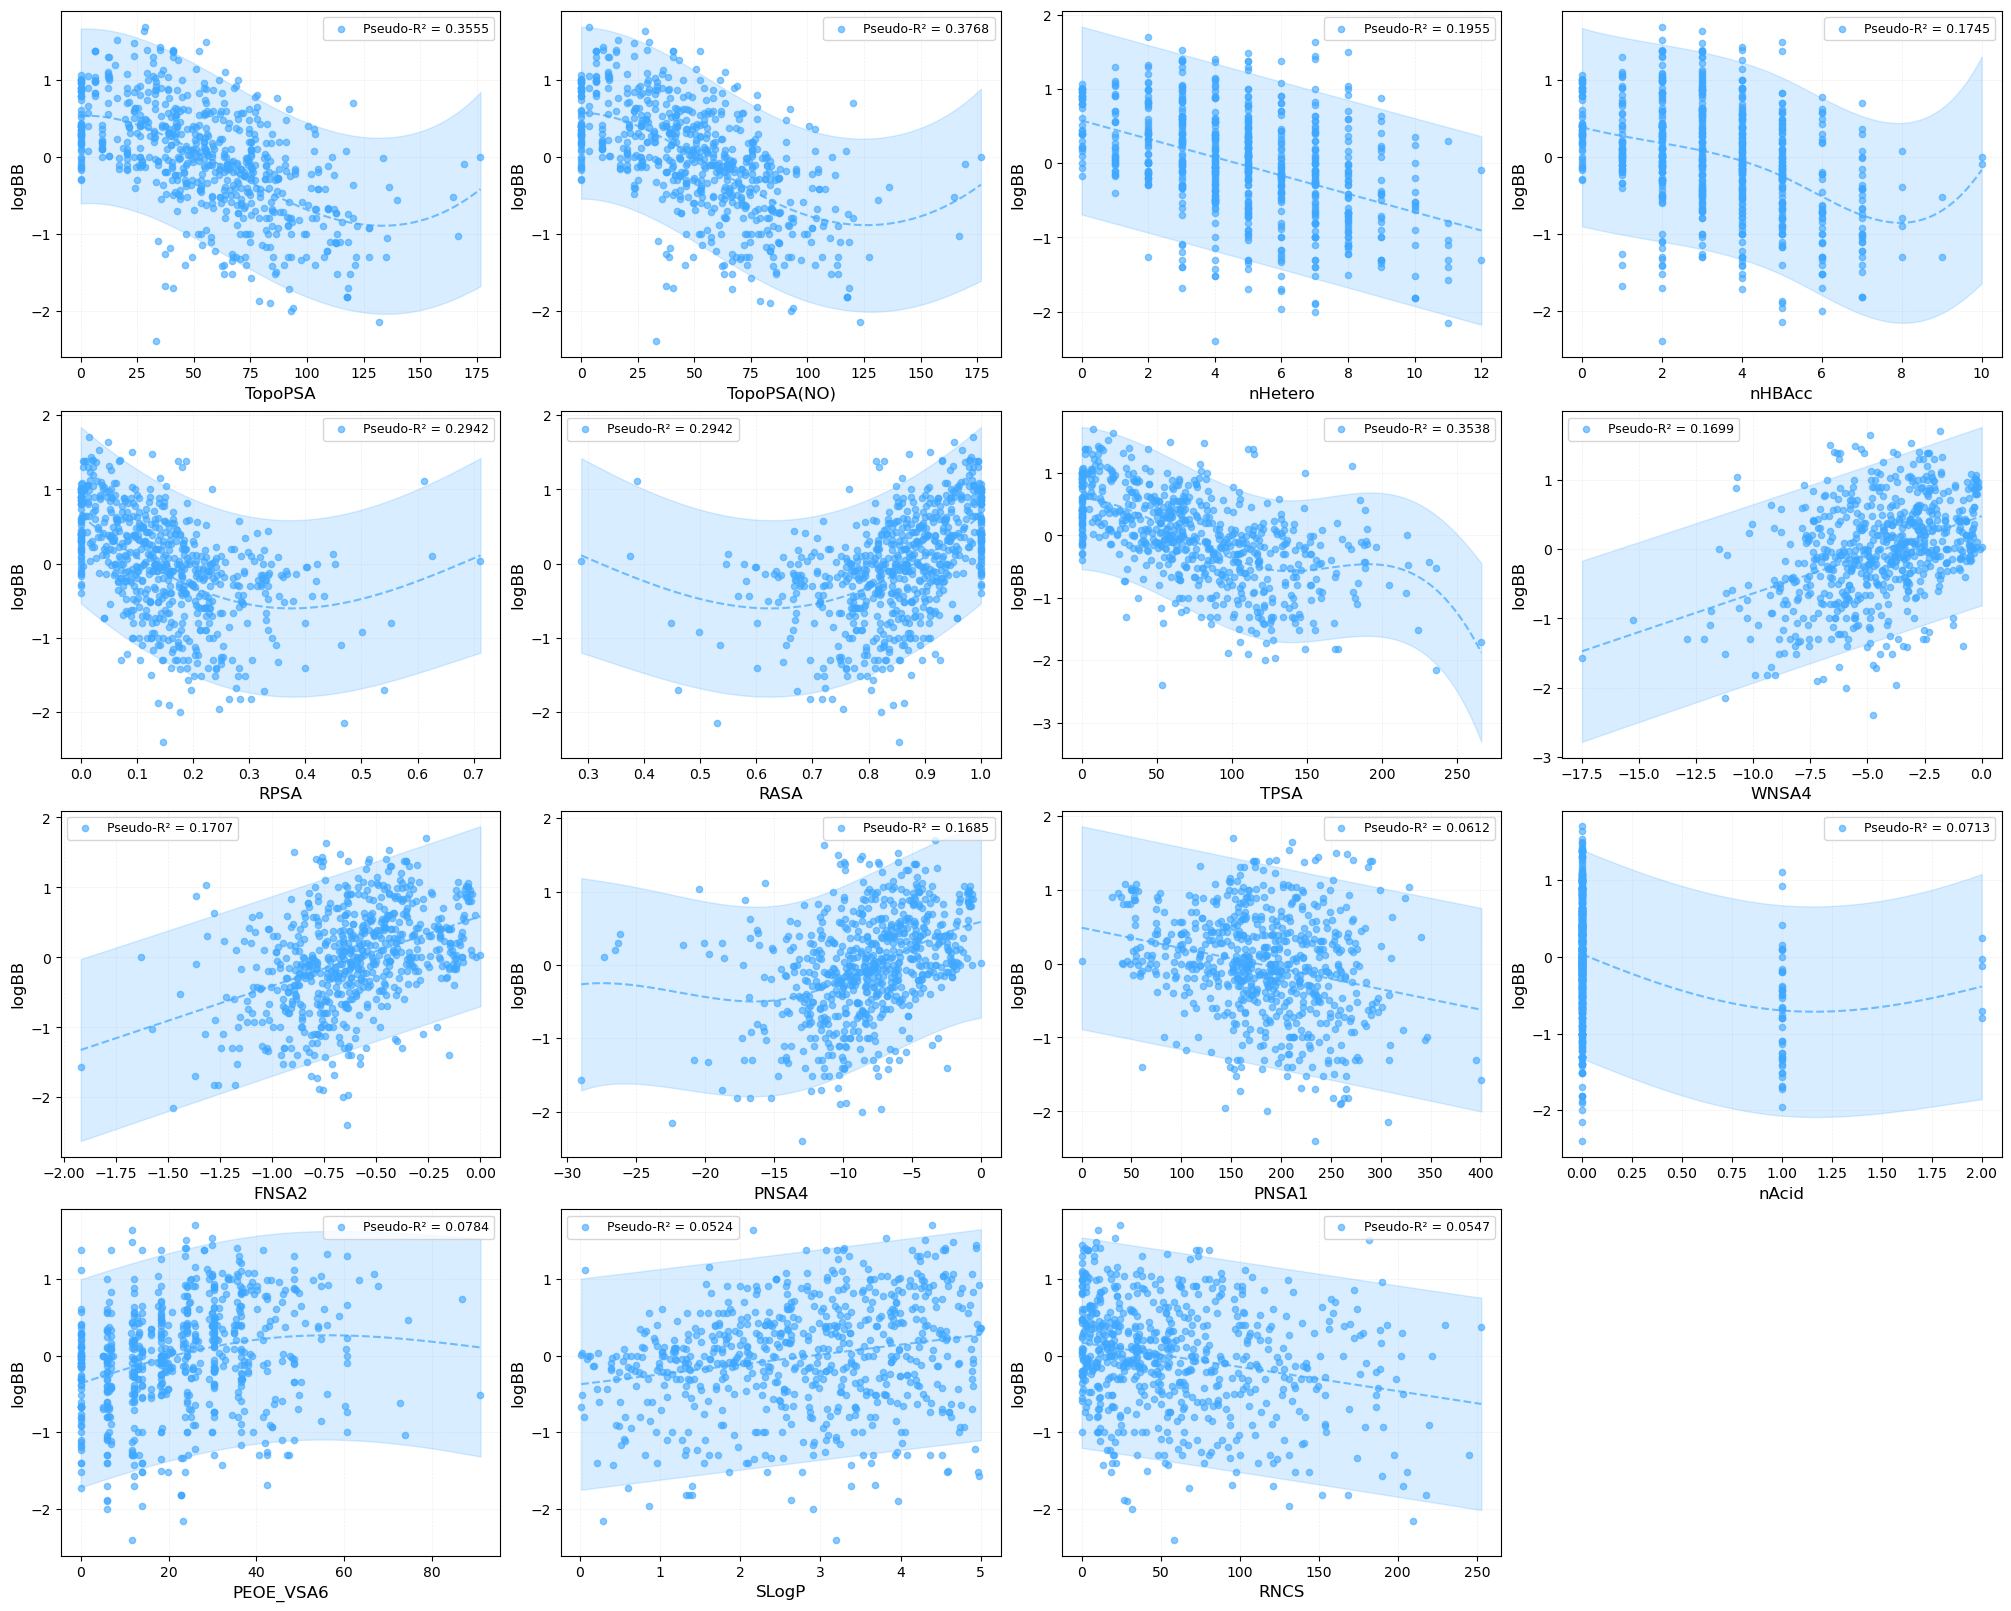

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 27% (3 of 11) |######                   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


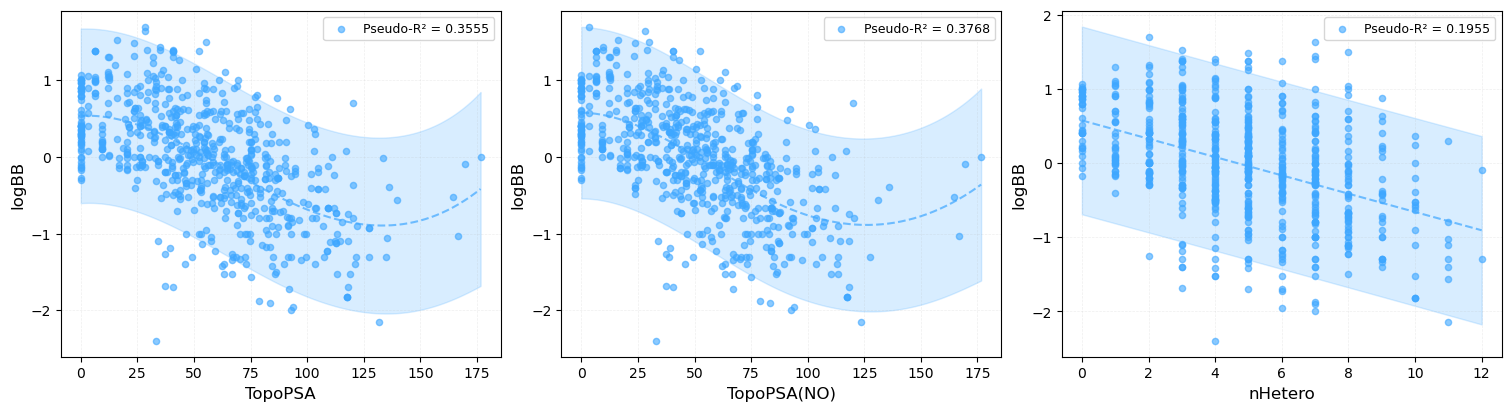

In [85]:
from pygam import LinearGAM, s
import numpy as np
import matplotlib.pyplot as plt

def plot_gam_panels(feature_indices, n_cols, save_path, colors, n_splines=5):
    """
    feature_indices: list of feature column indices to plot
    save_path: path to save the figure
    colors: list of colors to use for plotting
    n_splines: number of splines for GAM
    """
    n_features = len(feature_indices)
    n_rows = int(np.ceil(n_features / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), constrained_layout=True)
    axes = axes.flatten()
    
    for idx, col in enumerate(feature_indices):
        ax = axes[idx]

        X_subset = X_all[X_all[:, 2429]< 0.1]    
        logbb_subset = logbb[X_all[:, 2429] < 0.1]

        gam = LinearGAM(n_splines=n_splines).gridsearch(X_subset[:, [col]][~np.isnan(logbb_subset)], logbb_subset[~np.isnan(logbb_subset)])
        XX = gam.generate_X_grid(term=0, n=500)
        pred = gam.prediction_intervals(XX, width=0.95)
        pseudo_r2 = gam.statistics_['pseudo_r2']['explained_deviance']

        # 95% CI
        ax.fill_between(XX[:, 0], pred[:, 0], pred[:, 1],
                        alpha=0.2, color=colors[2], zorder=1)
        
        ax.plot(XX, gam.predict(XX), '--', color=colors[2], alpha=0.7, zorder=4)
        ax.scatter(X_subset[:, col][~np.isnan(logbb_subset)],
                   logbb_subset[~np.isnan(logbb_subset)],
                   facecolor=colors[2], alpha=0.6, s=20,
                   label=f'Pseudo-R\u00B2 = {pseudo_r2:.4f}', zorder=3)
        
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.2, zorder=0)
        ax.set_xlabel(f'{list(X_full_no_nan.columns)[col]}', fontsize=12)
        ax.set_ylabel('logBB', fontsize=12)
        ax.legend(fontsize=9)
        ax.tick_params(axis='both', labelsize=10)

    # Remove unused subplots
    for ax in axes[n_features:]:
        fig.delaxes(ax)

    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)


plot_gam_panels(
    feature_indices=l_cols,
    n_cols=4,
    # title='GAM Regression for All 20 Features from the Top 10 Feature-Clusters',
    save_path=f'./results/regression_gams/gam_all_features.png',
    colors=colors
)


# subset = [0,1,2,4] 
plot_gam_panels(
    feature_indices=l_cols[:3],
    n_cols=3,
    # title='GAM Regression for Selected Features',
    save_path=f'./results/regression_gams/gam_selected_features.png',
    colors=colors
)


Global log scale range: 7.0 – 692.0


/var/folders/6v/8cht_hkj5z36tsf8szmrhkrh0000gp/T/ipykernel_36322/1717788744.py:75: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


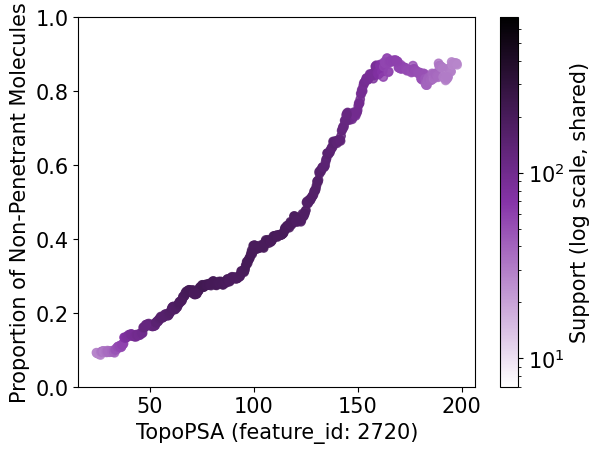

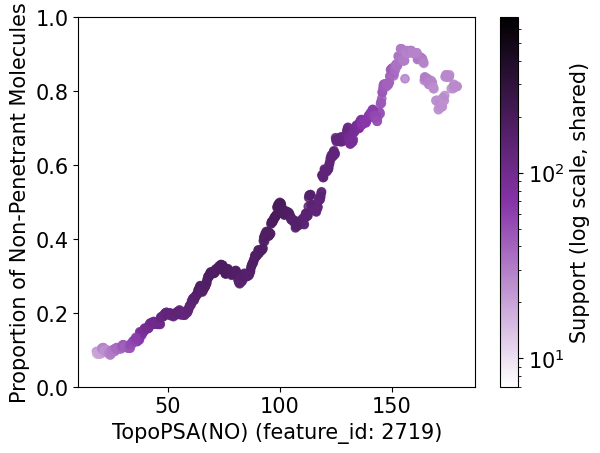

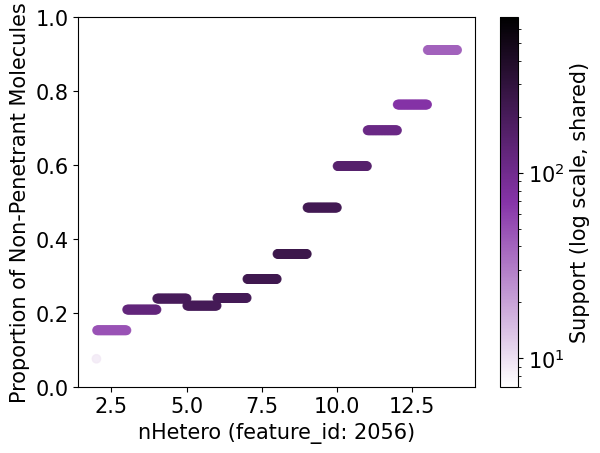

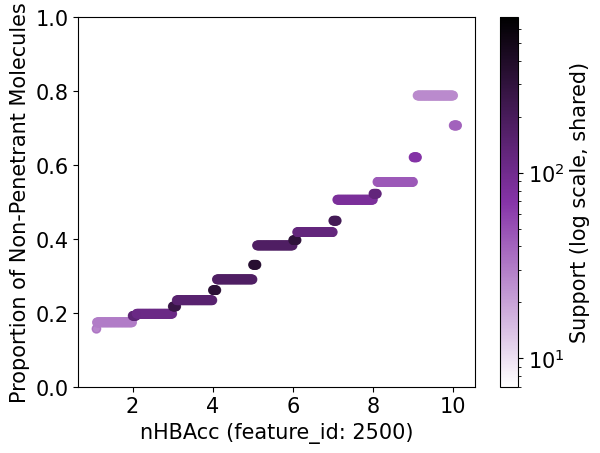

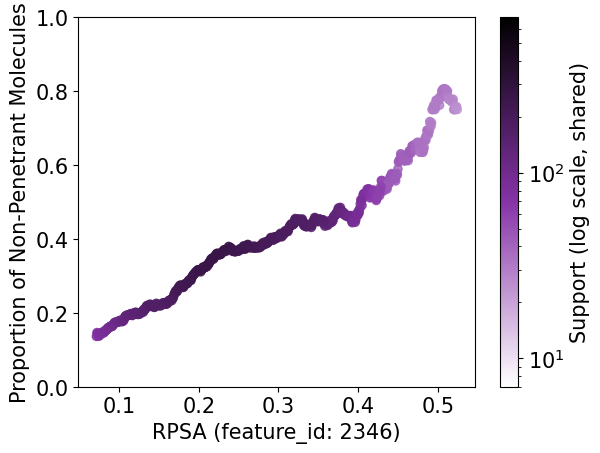

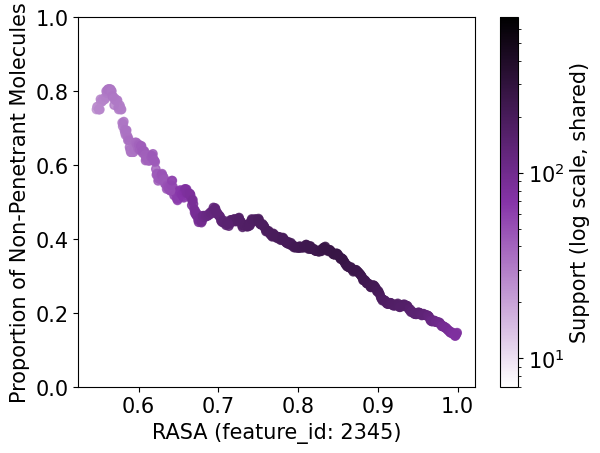

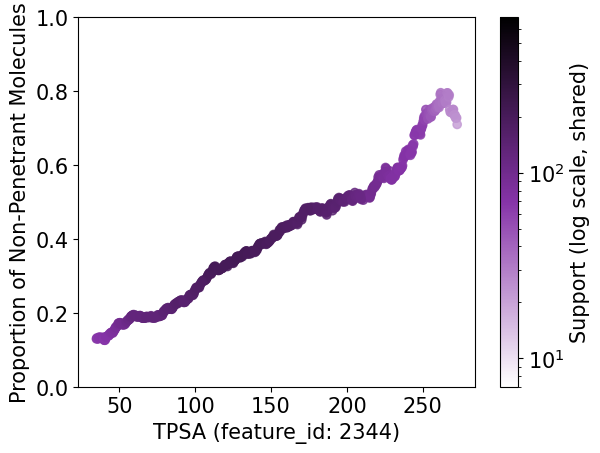

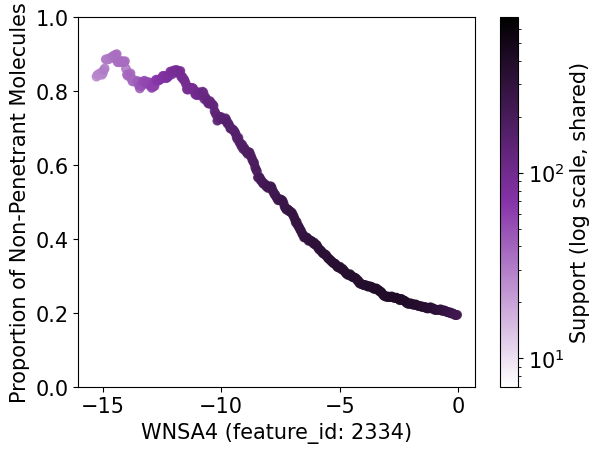

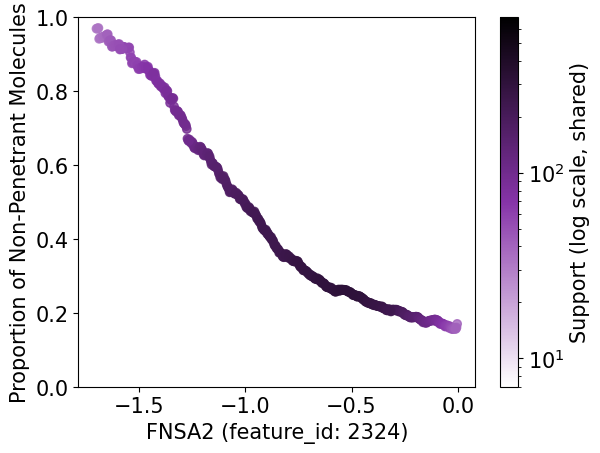

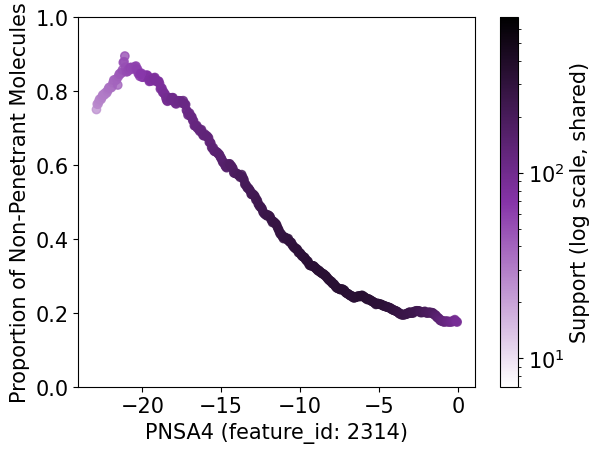

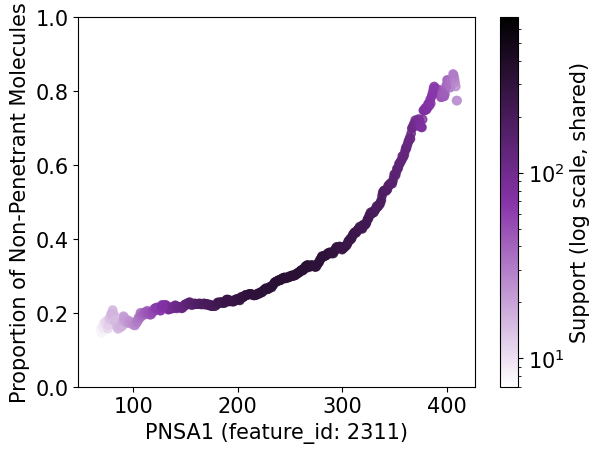

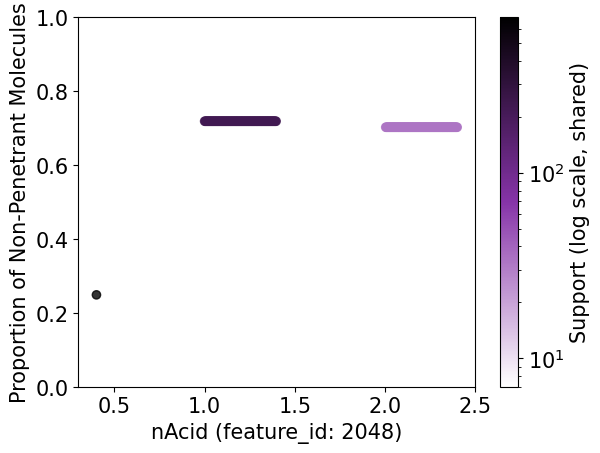

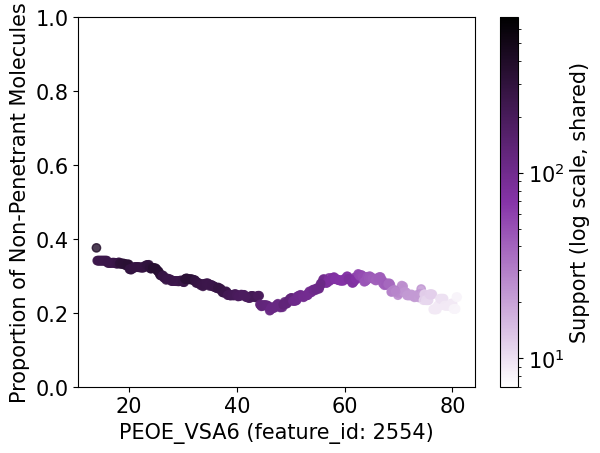

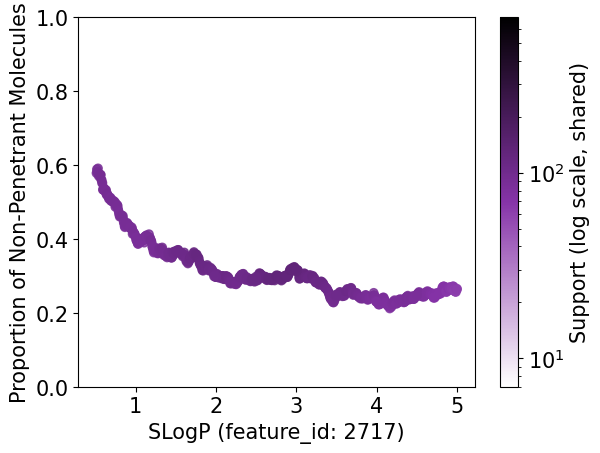

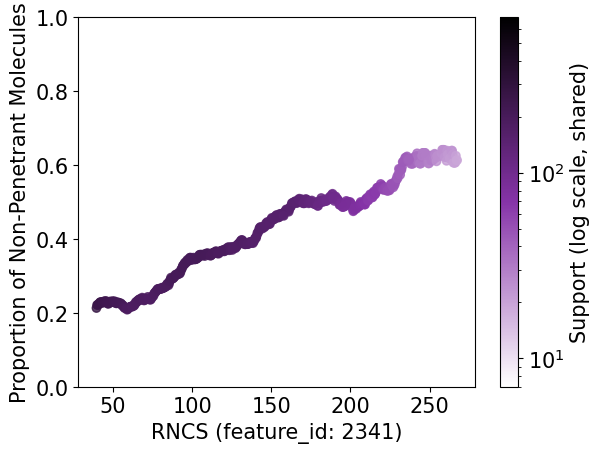

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, LogNorm

all_instances = []



for col in l_cols:
    for step in range(100):
        feature_max = np.max(X_all[:, [col]])
        feature_min = np.min(X_all[:, [col]])
        feature_range = feature_max - feature_min
        bins = np.arange(feature_min + (feature_range * step) / 1000,
                         feature_max, feature_range / 10)
        bin_indices = np.digitize(np.array(X_all[:, [col]]), bins, right=False)

        for i in range(1, len(bins)):
            in_bin = bin_indices == i
            in_bin = [x for xs in in_bin for x in xs]
            count = np.sum(np.array(in_bin).astype(int))
            if count > 30:
                all_instances.append(np.sum(bbb_class[in_bin]))


global_min = max(1, np.min(all_instances))
global_max = np.max(all_instances)

print(f"Global log scale range: {global_min:.1f} – {global_max:.1f}")


skyblue_cmap = LinearSegmentedColormap.from_list(
    'skyblue_custom',
    ['#FFFFFF', colors[3],'black']
)
norm = LogNorm(vmin=global_min, vmax=global_max)

n_bbb_np = np.sum(bbb_class == 1)


for col in l_cols: 
    for step in range(100):

        feature_max = np.max(X_all[:, [col]])
        feature_min = np.min(X_all[:, [col]])
        feature_range = feature_max - feature_min
        bins = np.arange(feature_min + (feature_range * step) / 1000,
                         feature_max,
                         feature_range / 10)
        bin_indices = np.digitize(np.array(X_all[:, [col]]), bins, right=False)
        proportion_np, bins_available = [], []
        instances = []

        for i in range(1, len(bins)):
            in_bin = bin_indices == i
            in_bin = [x for xs in in_bin for x in xs]
            if np.sum(np.array(in_bin).astype(int)) > 30:
                avg = bbb_class[in_bin].mean()
                instances.append(np.sum(bbb_class[in_bin]))
                proportion_np.append(avg)
                bins_available.append(bins[i])

        instances_arr = np.array(instances)
        color_based_on_support = [skyblue_cmap(norm(n)) for n in instances_arr]

        plt.scatter(bins_available, proportion_np, color=color_based_on_support, alpha=0.8)
        plt.xlabel(f'{list(X_full_no_nan.columns)[col]} (feature_id: {col})')
        plt.ylabel('Proportion of Non-Penetrant Molecules')
        plt.ylim((0, 1))

    # Shared log-scaled colorbar
    sm = cm.ScalarMappable(cmap=skyblue_cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm)
    cbar.set_label('Support (log scale, shared)')
    
    # plt.savefig(f'./feature_ratios/feature_ratios_{list(X_full_no_nan.columns)[col]}.png', dpi=300)
    plt.show()
    plt.close()


Global log scale range: 12.0 – 113.0


/var/folders/6v/8cht_hkj5z36tsf8szmrhkrh0000gp/T/ipykernel_36322/967023483.py:82: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


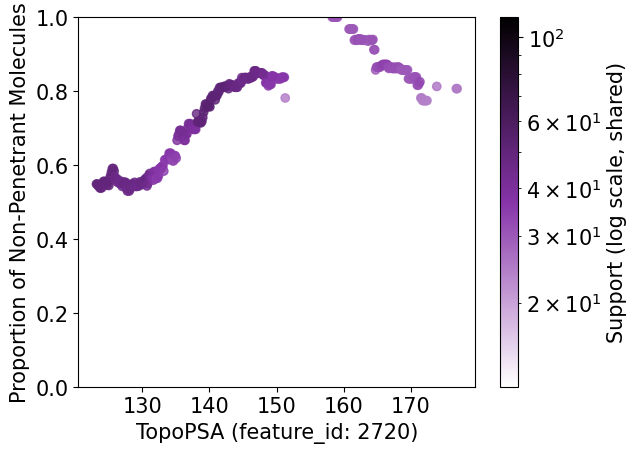

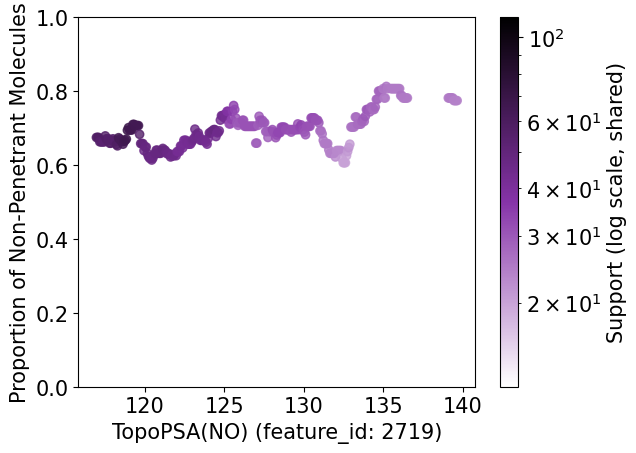

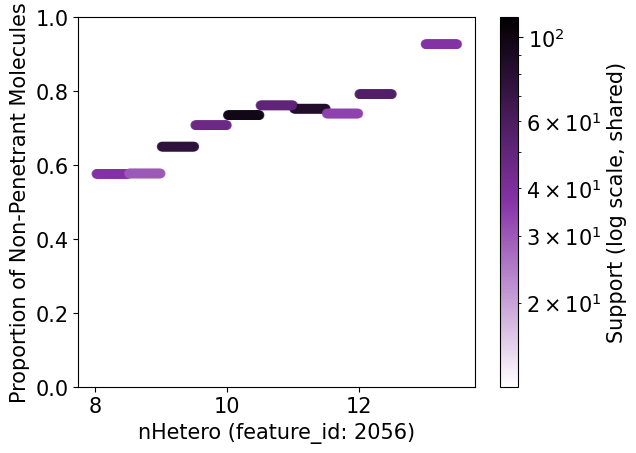

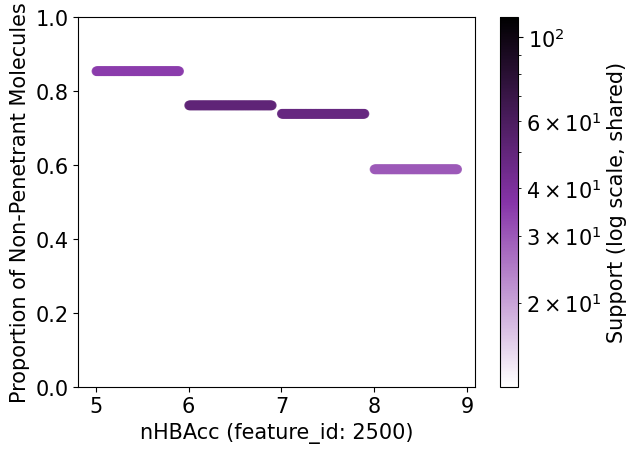

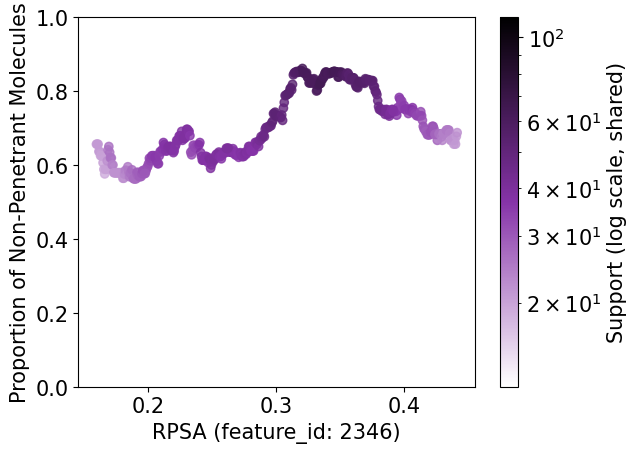

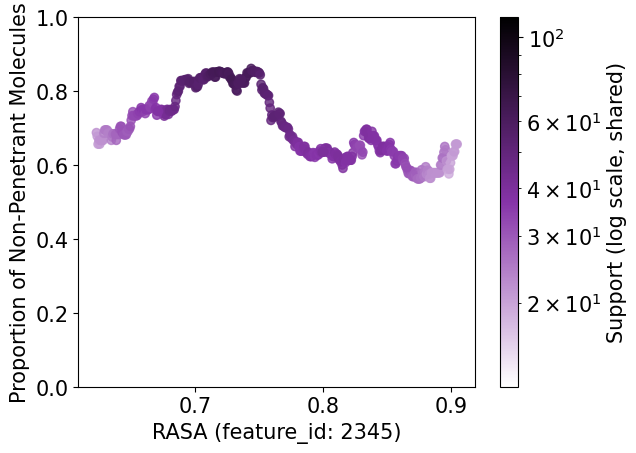

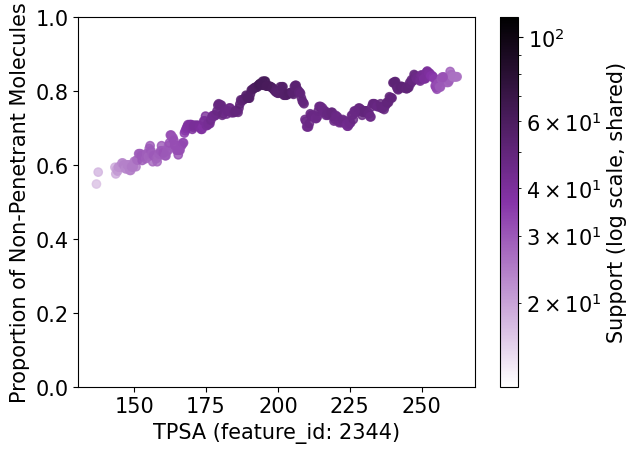

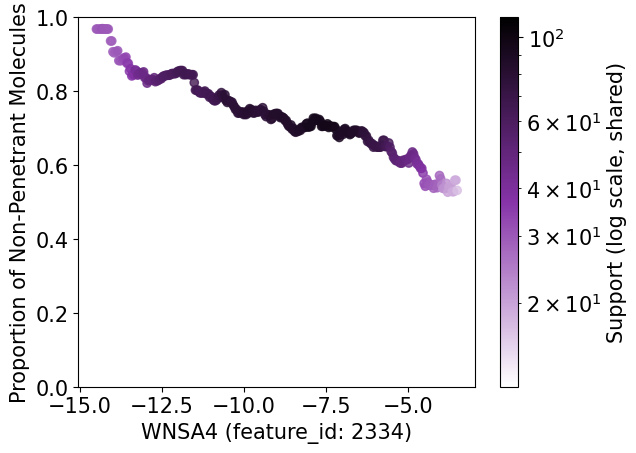

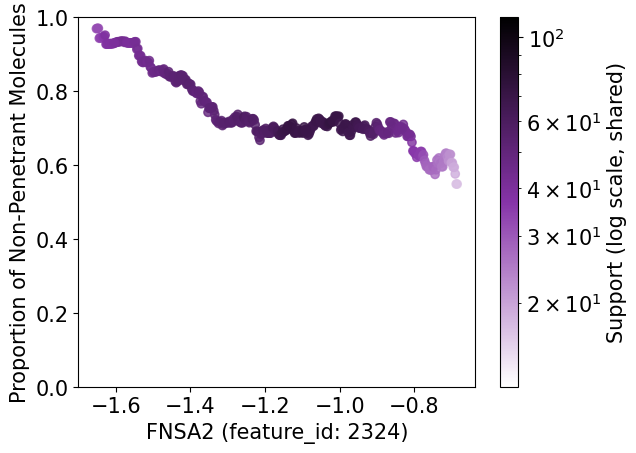

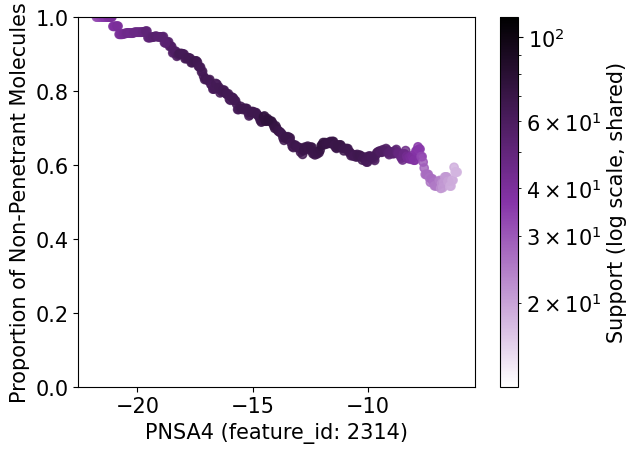

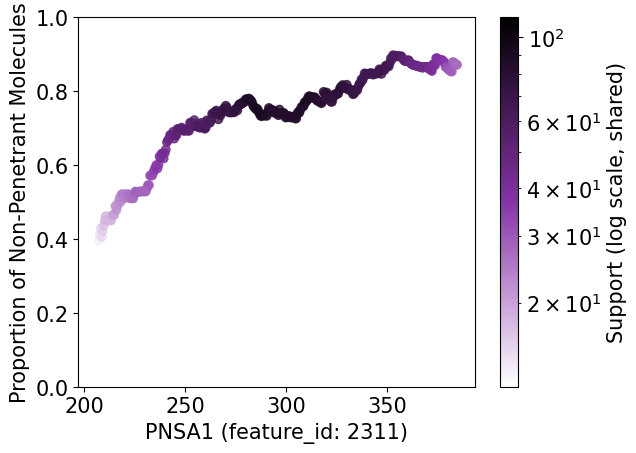

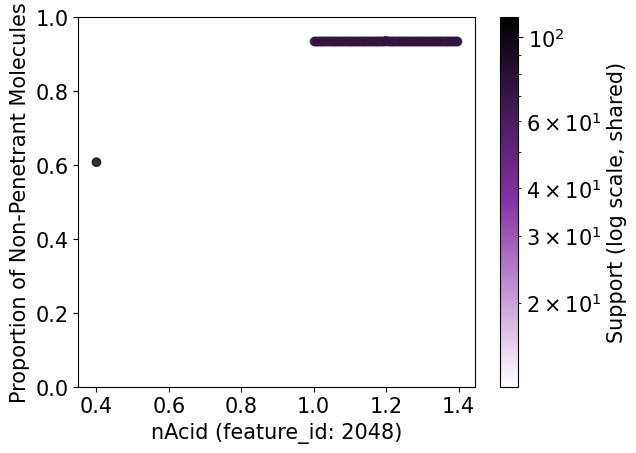

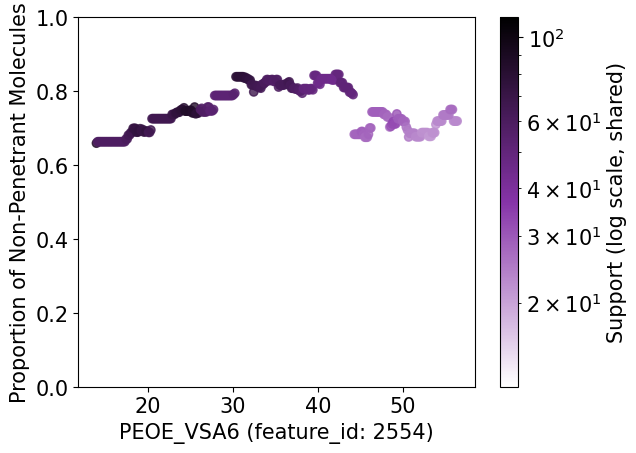

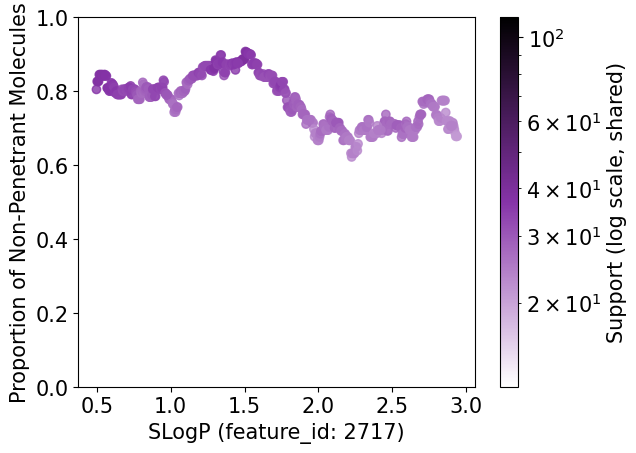

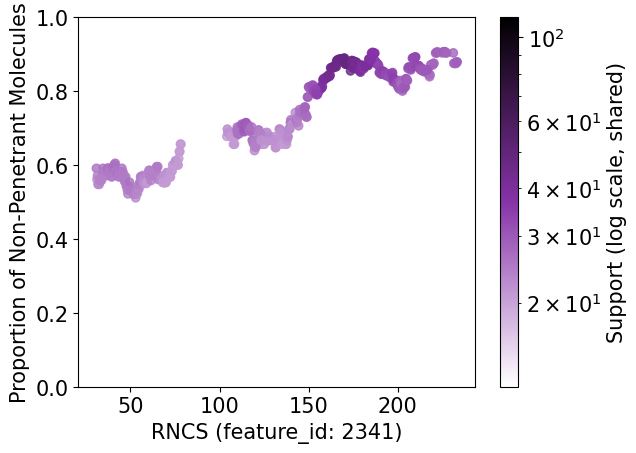

In [86]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, LogNorm

all_instances = []

topopsa_mask = X_all[:,l_cols[1]] > 110
X_all_topopsano = X_all[topopsa_mask]
bbb_class_topopsano = np.asarray(bbb_class)[topopsa_mask]

# nh_mask = X_all_topopsano[:,top_fture_ids[1]] > 8

# X_all_topopsano = X_all_topopsano[nh_mask]
# bbb_class_topopsano = np.asarray(bbb_class_topopsano)[nh_mask]

for col in l_cols:
    for step in range(100):
        feature_max = np.max(X_all_topopsano[:, [col]])
        feature_min = np.min(X_all_topopsano[:, [col]])
        feature_range = feature_max - feature_min
        bins = np.arange(feature_min + (feature_range * step) / 1000,
                         feature_max, feature_range / 10)
        bin_indices = np.digitize(np.array(X_all_topopsano[:, [col]]), bins, right=False)

        for i in range(1, len(bins)):
            in_bin = bin_indices == i
            in_bin = [x for xs in in_bin for x in xs]
            count = np.sum(np.array(in_bin).astype(int))
            if count > 30:
                all_instances.append(np.sum(bbb_class_topopsano[in_bin]))


global_min = max(1, np.min(all_instances))
global_max = np.max(all_instances)

print(f"Global log scale range: {global_min:.1f} – {global_max:.1f}")


skyblue_cmap = LinearSegmentedColormap.from_list(
    'skyblue_custom',
    ['#FFFFFF', colors[3],'black']
)
norm = LogNorm(vmin=global_min, vmax=global_max)

n_bbb_np = np.sum(bbb_class_topopsano == 1)


for col in l_cols: 
    for step in range(100):

        feature_max = np.max(X_all_topopsano[:, [col]])
        feature_min = np.min(X_all_topopsano[:, [col]])
        feature_range = feature_max - feature_min
        bins = np.arange(feature_min + (feature_range * step) / 1000,
                         feature_max,
                         feature_range / 10)
        bin_indices = np.digitize(np.array(X_all_topopsano[:, [col]]), bins, right=False)
        proportion_np, bins_available = [], []
        instances = []

        for i in range(1, len(bins)):
            in_bin = bin_indices == i
            in_bin = [x for xs in in_bin for x in xs]
            if np.sum(np.array(in_bin).astype(int)) > 30:
                avg = bbb_class_topopsano[in_bin].mean()
                instances.append(np.sum(bbb_class_topopsano[in_bin]))
                proportion_np.append(avg)
                bins_available.append(bins[i])

        instances_arr = np.array(instances)
        color_based_on_support = [skyblue_cmap(norm(n)) for n in instances_arr]

        plt.scatter(bins_available, proportion_np, color=color_based_on_support, alpha=0.8)
        plt.xlabel(f'{list(X_full_no_nan.columns)[col]} (feature_id: {col})')
        plt.ylabel('Proportion of Non-Penetrant Molecules')
        plt.ylim((0, 1))

    # Shared log-scaled colorbar
    sm = cm.ScalarMappable(cmap=skyblue_cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm)
    cbar.set_label('Support (log scale, shared)')
    
    # plt.savefig(f'./feature_ratios/feature_ratios_{list(X_full_no_nan.columns)[col]}.png', dpi=300)
    plt.show()
    plt.close()


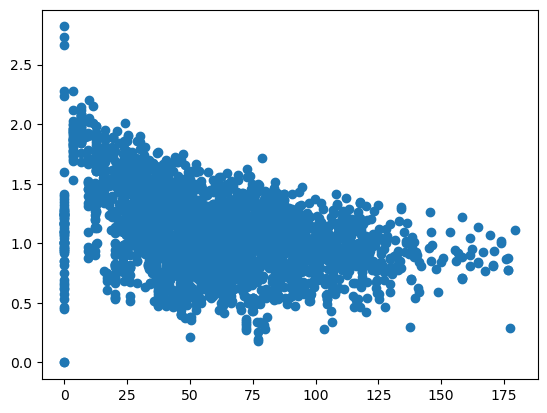

In [83]:
topopsa = X_full_no_nan.iloc[:, int(top_feature_ids[0])].to_numpy(dtype=float)
n_hetero = X_full_no_nan.iloc[:, int(top_feature_ids[13])].to_numpy(dtype=float)

plt.scatter(topopsa, n_hetero)

In [84]:
import pandas as pd

top_feature_ids = [int(i) for i in top_feature_ids]

top_feature_df = X_full_no_nan.iloc[:, top_feature_ids].copy()

topopsa_col = X_full_no_nan.columns[int(top_feature_ids[0])]

correlations = (
    top_feature_df
    .corr(method="pearson")[topopsa_col]
    .drop(index=topopsa_col)
    .sort_values(key=abs, ascending=False)
)

print(correlations)

TopoPSA      0.953292
TPSA         0.831311
nHetero      0.815578
FNSA2       -0.781257
FNSA2       -0.781257
WNSA5       -0.771191
WNSA4       -0.732615
NdO          0.716730
SdO          0.716532
RASA        -0.683936
RPSA         0.683936
nBondsD      0.658272
FPSA5        0.517450
FPSA4        0.492342
GATS2c      -0.436008
nAcid        0.303923
SLogP       -0.293591
PEOE_VSA6   -0.189640
ATSC3s      -0.165367
Name: TopoPSA(NO), dtype: float64


In [43]:
import numpy as np
import pandas as pd

top_feature_ids = [int(i) for i in l_cols]
topopsa_col = "TopoPSA(NO)"

# Restrict the rows first
high_topopsa_mask = X_full_no_nan[topopsa_col] > 110

subset = X_full_no_nan.loc[
    high_topopsa_mask,
    X_full_no_nan.columns[top_feature_ids],
].copy()

# Correlation with TopoPSA(NO) within this restricted subset
correlations = (
    subset.corr(method="pearson")[topopsa_col]
    .drop(index=topopsa_col)
    .dropna()
)

lowest_correlation = (
    correlations
    .rename("pearson_r")
    .to_frame()
    .assign(absolute_r=lambda df: df["pearson_r"].abs())
    .sort_values("absolute_r", ascending=True)
)

print(f"Compounds with TopoPSA(NO) > 110: {len(subset)}")
print(lowest_correlation)

Compounds with TopoPSA(NO) > 110: 298
            pearson_r  absolute_r
nO           0.352153    0.352153
TPSA         0.354652    0.354652
SlogP_VSA2   0.354669    0.354669
SMR_VSA1     0.361377    0.361377
PEOE_VSA1    0.446907    0.446907
PNSA3       -0.457931    0.457931
nHBAcc       0.477370    0.477370
DPSA3        0.531160    0.531160
DPSA4        0.555951    0.555951
ATSC0c       0.557943    0.557943
ATSC1c      -0.569601    0.569601
TopoPSA      0.754304    0.754304


Global log scale range: 7.0 – 692.0


FileNotFoundError: [Errno 2] No such file or directory: './feature_ratios/all_features.png'

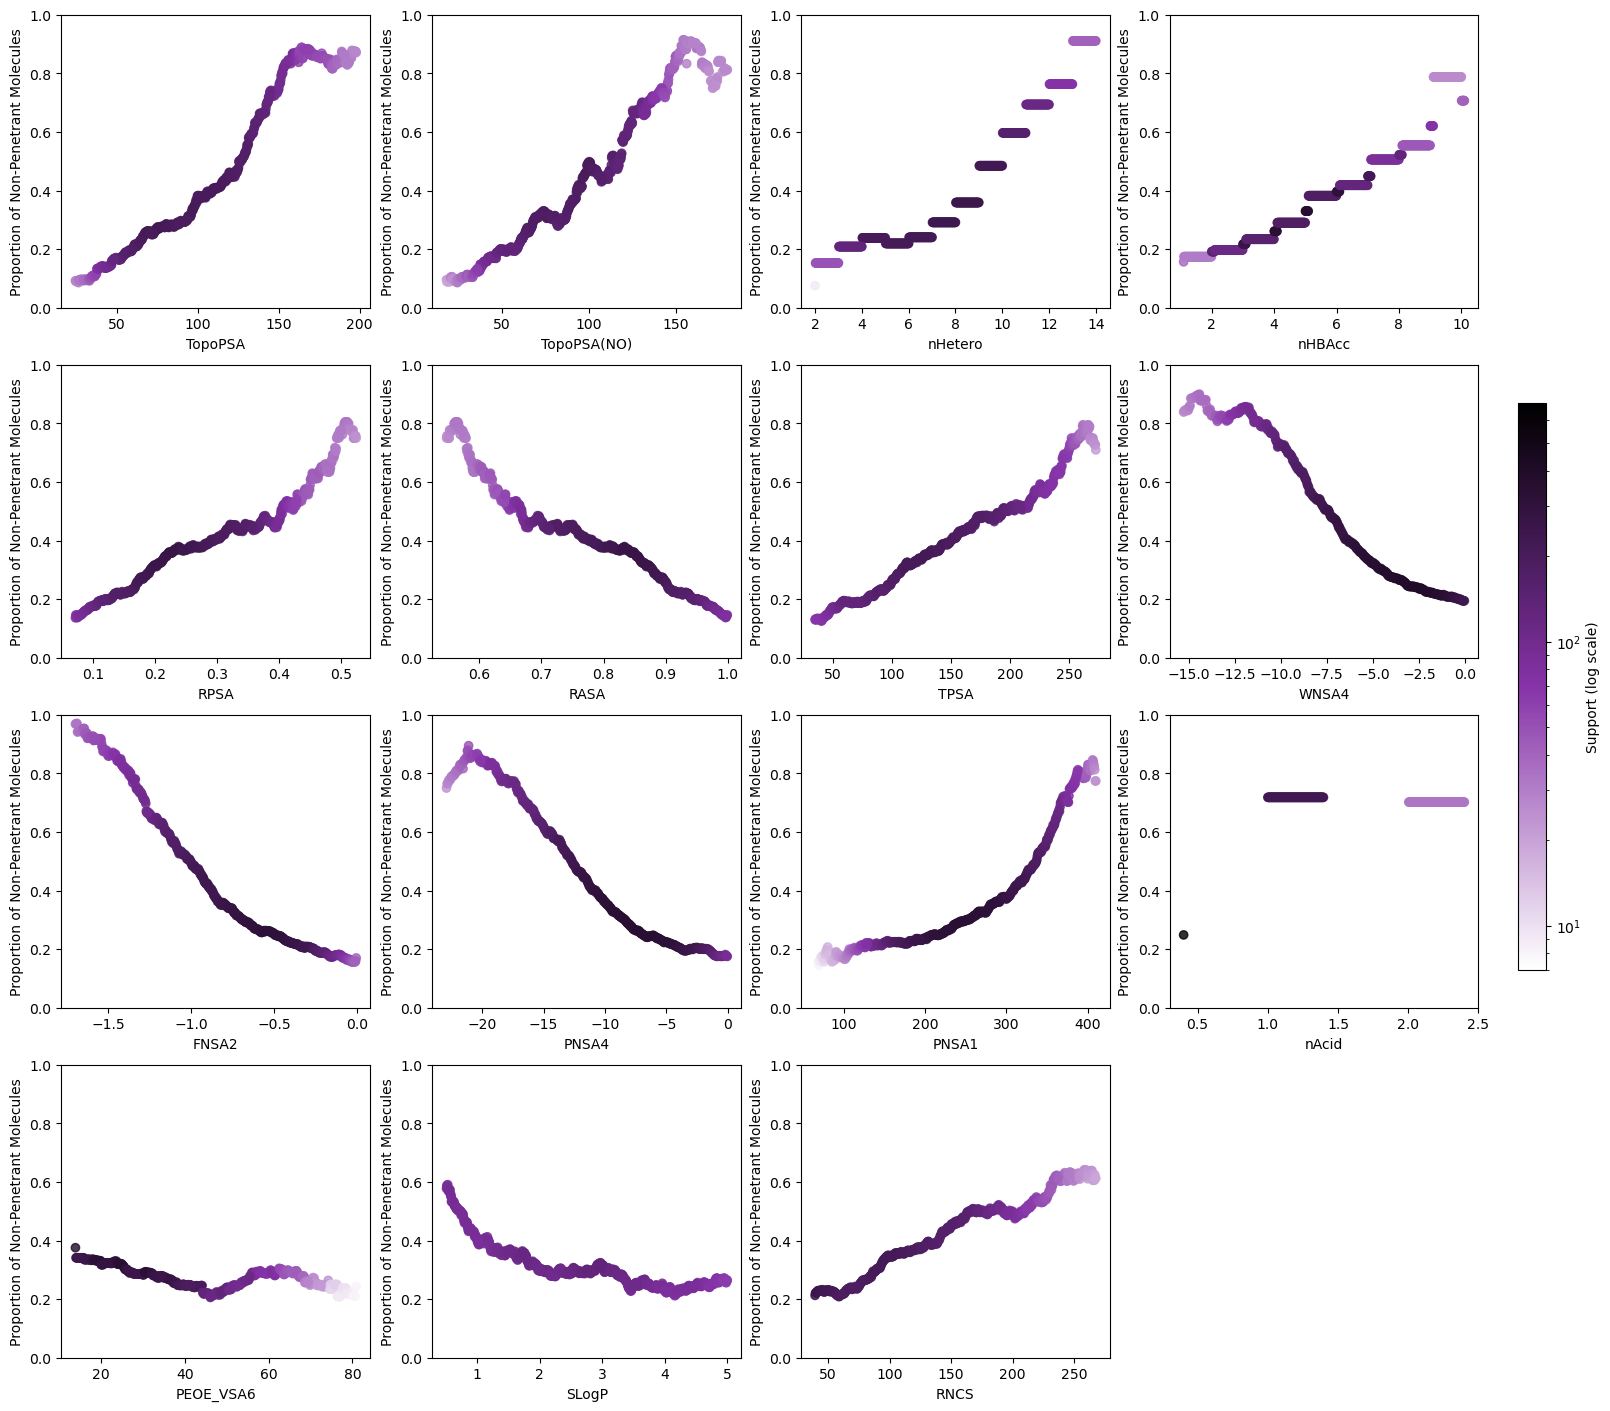

In [88]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap, LogNorm

plt.rcParams.update({'font.size': 10})

all_instances = []

for col in l_cols:
    for step in range(100):
        feature_max = np.max(X_all[:, [col]])
        feature_min = np.min(X_all[:, [col]])
        feature_range = feature_max - feature_min
        bins = np.arange(feature_min + (feature_range * step) / 1000,
                         feature_max,
                         feature_range / 10)
        bin_indices = np.digitize(np.array(X_all[:, [col]]), bins, right=False)

        for i in range(1, len(bins)):
            in_bin = bin_indices == i
            in_bin = [x for xs in in_bin for x in xs]
            count = np.sum(np.array(in_bin).astype(int))
            if count > 30:
                all_instances.append(np.sum(bbb_class[in_bin]))

global_min = max(1, np.min(all_instances))
global_max = np.max(all_instances)
print(f"Global log scale range: {global_min:.1f} – {global_max:.1f}")

custom_cmap = LinearSegmentedColormap.from_list(
    'custom_cmap',
    ['#FFFFFF', colors[3],'black']
)
norm = LogNorm(vmin=global_min, vmax=global_max)

def plot_feature_panels(feature_indices, n_cols, title, save_path):
    n_features = len(feature_indices)
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), constrained_layout=True)
    axes = axes.flatten()

    for idx, col in enumerate(feature_indices):
        ax = axes[idx]
        all_proportion_np, all_bins_available, all_instances = [], [], []

        for step in range(100):
            feature_max = np.max(X_all[:, [col]])
            feature_min = np.min(X_all[:, [col]])
            feature_range = feature_max - feature_min
            bins = np.arange(feature_min + (feature_range * step) / 1000,
                             feature_max,
                             feature_range / 10)
            bin_indices = np.digitize(np.array(X_all[:, [col]]), bins, right=False)

            proportion_np, bins_available, instances = [], [], []

            for i in range(1, len(bins)):
                in_bin = bin_indices == i
                in_bin = [x for xs in in_bin for x in xs]
                if np.sum(np.array(in_bin).astype(int)) > 30:
                    avg = bbb_class[in_bin].mean()
                    instances.append(np.sum(bbb_class[in_bin]))
                    proportion_np.append(avg)
                    bins_available.append(bins[i])

            if len(instances) > 0:
                all_proportion_np.extend(proportion_np)
                all_bins_available.extend(bins_available)
                all_instances.extend(instances)

        # color according to shared log scale
        instances_arr = np.array(all_instances)
        if len(instances_arr) > 0:
            color_based_on_support = [custom_cmap(norm(n)) for n in instances_arr]
            ax.scatter(all_bins_available, all_proportion_np, color=color_based_on_support, alpha=0.8)

        ax.set_xlabel(f'{list(X_full_no_nan.columns)[col]}')
        ax.set_ylabel('Proportion of Non-Penetrant Molecules')
        ax.set_ylim((0, 1))

    # Remove unused subplots
    for ax in axes[n_features:]:
        fig.delaxes(ax)

    # Shared colorbar
    sm = cm.ScalarMappable(cmap=skyblue_cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, location='right', pad=0.02, fraction=0.02)
    cbar.set_label('Support (log scale)')

    plt.savefig(save_path, dpi=300) 
    plt.show()
    plt.close(fig)

plot_feature_panels(l_cols, 4,'Feature Ratios From the 10 Most Important Feature Clusters', f'./feature_ratios/all_features.png')

# subset
# subset_indices = [0, 1, 2, 4, 6, 9]
plot_feature_panels(l_cols[:3], 3, 'Selected Feature Ratios', f'./model_evaluation/{ds}/feature_ratios/selected_features.png')


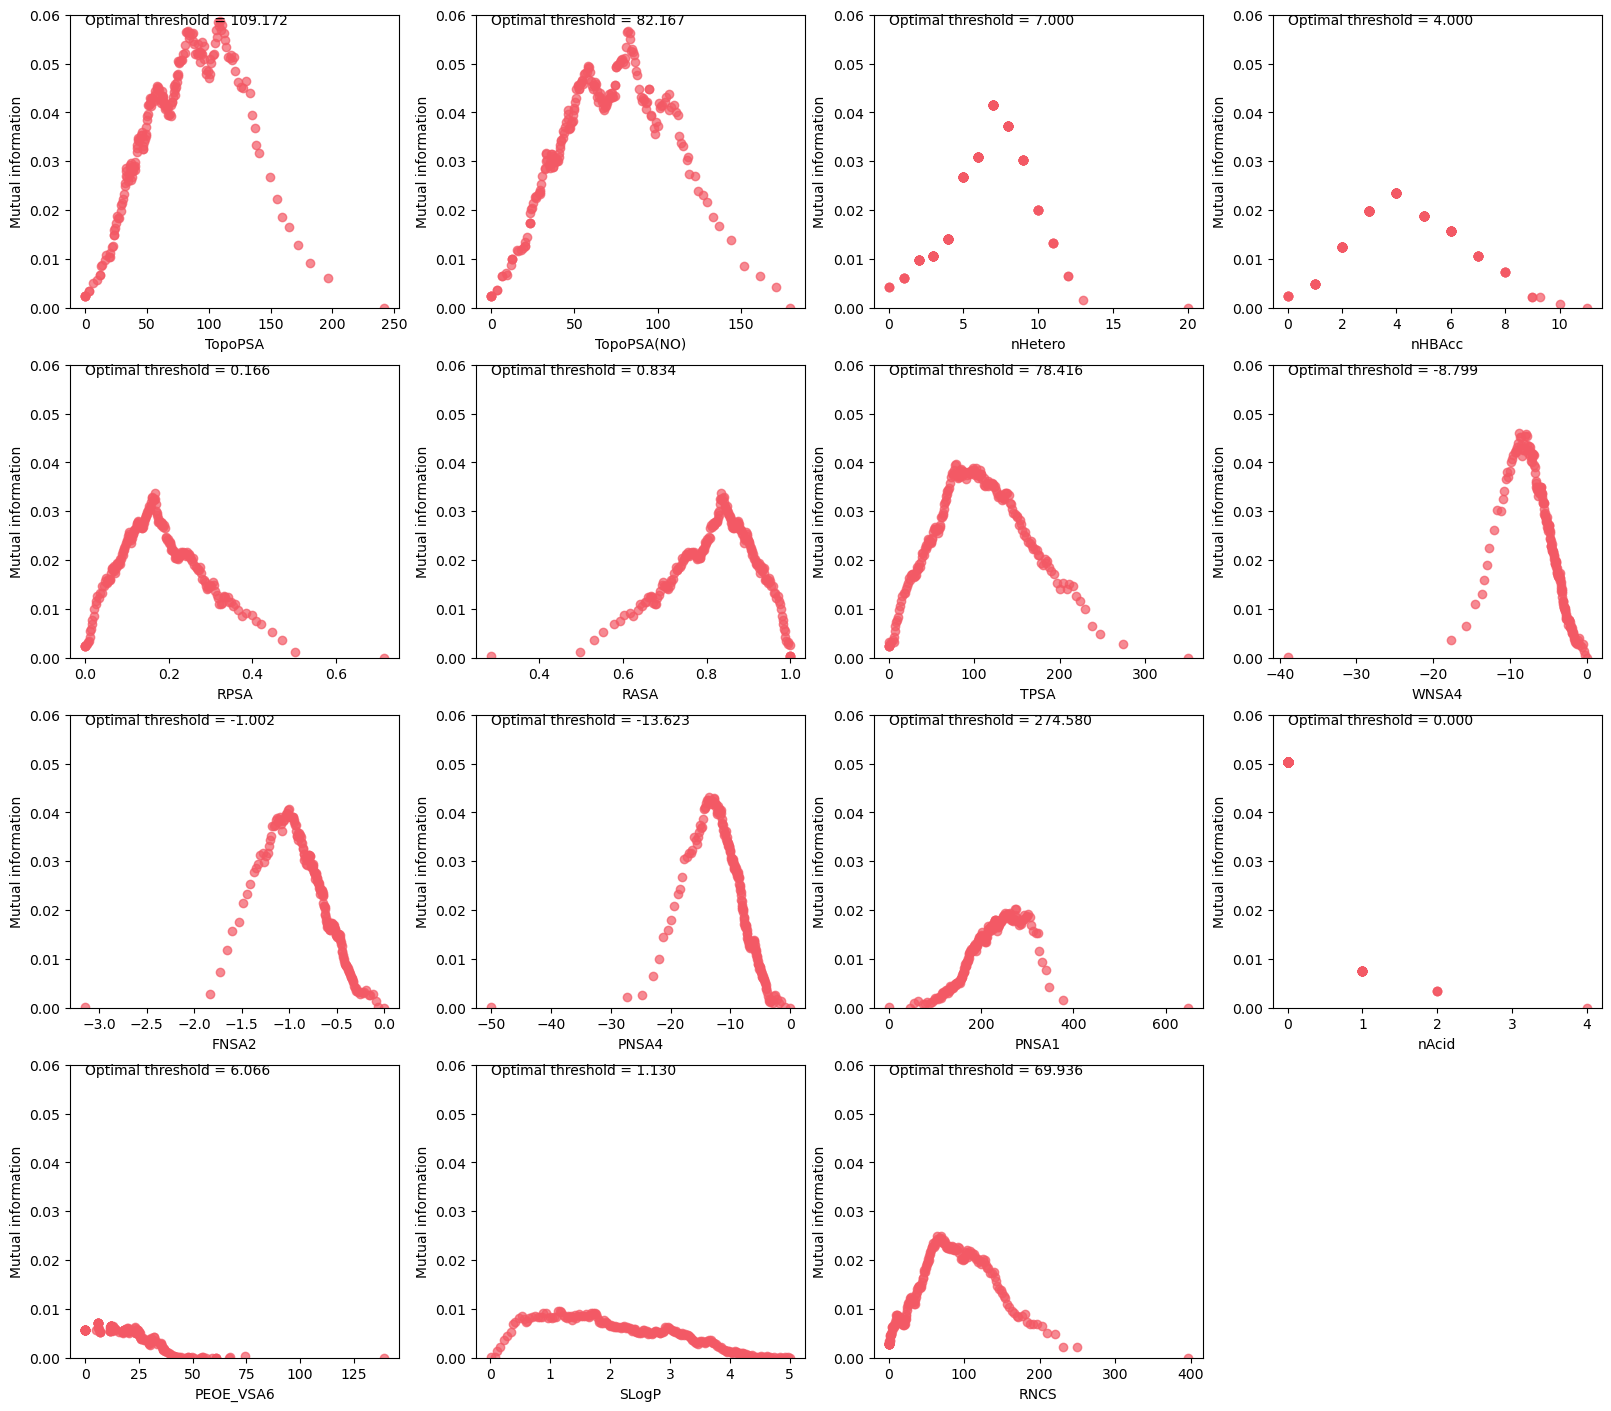

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve
import numpy as np
from sklearn.metrics import mutual_info_score

def threshold_mutual_information(feature, y, bins=200):

    thresholds = np.quantile(feature, np.linspace(0, 1, bins))
    
    MIs = []
    for t in thresholds:
        rule = (feature > t).astype(int)
        MI = mutual_info_score(rule, y)
        MIs.append(MI)

    return thresholds, MIs


def plot_optimal_mi_panels(df, feature_indices, bbb_class, n_cols, save_path):
    n_features = len(feature_indices)
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), constrained_layout=True)
    axes = axes.flatten()

    for idx, col in enumerate(feature_indices):
        ax = axes[idx]

        feature = np.array(df.iloc[:, col])

        thresholds, MIs = threshold_mutual_information(feature, bbb_class)
        
        best_idx = np.argmax(MIs)

        ax.scatter(thresholds, MIs, color=colors[0], alpha=0.7)
        ax.text(np.min(feature),0.057,f'Optimal threshold = {thresholds[best_idx]:.3f}')

        ax.set_xlabel(f'{list(X_full_no_nan.columns)[col]}')
        ax.set_ylabel('Mutual information')
        ax.set_ylim((0, 0.06))

    # Remove unused subplots
    for ax in axes[n_features:]:
        fig.delaxes(ax)

    plt.savefig(save_path, dpi=300) #, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    
    return 

plot_optimal_mi_panels(X_full_no_nan, l_cols, bbb_class, 4, f'./results/mutual_information_all.png')



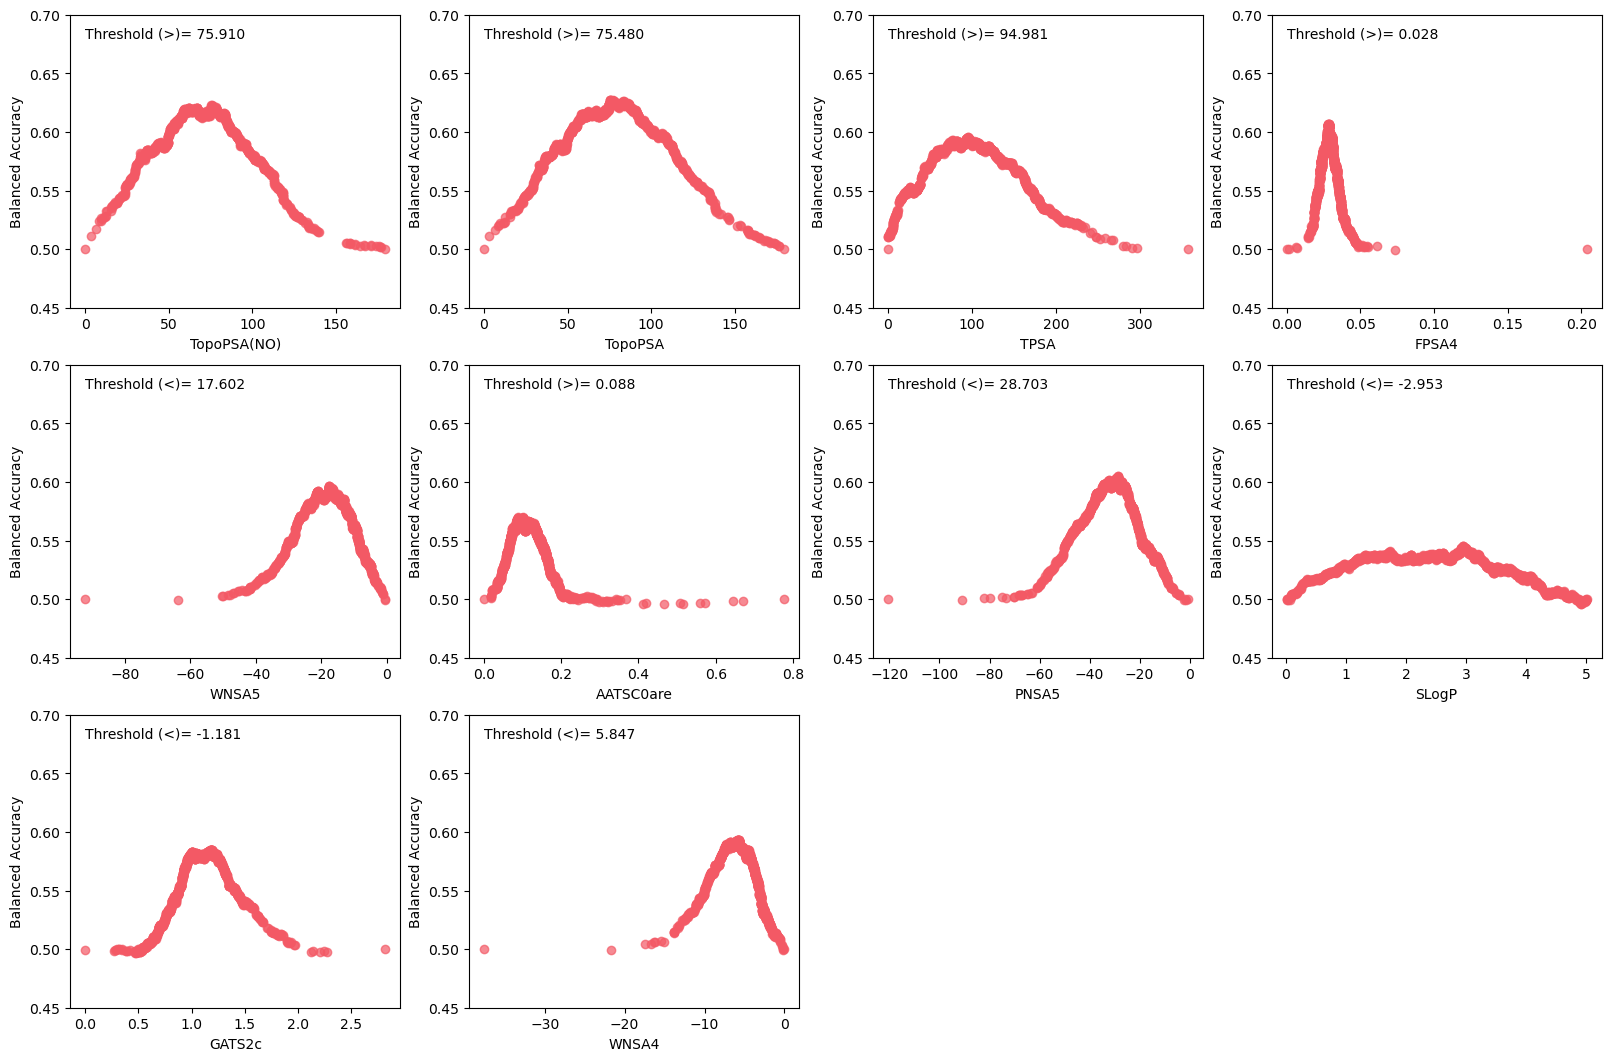

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve
import numpy as np
from sklearn.metrics import mutual_info_score


def optimal_threshold_ba(feature, y, min_=False):
    """
    Returns the threshold t that maximizes Youden's J = TPR - FPR.
    feature: array-like (continuous feature)
    y: array-like (binary labels)
    """
    if np.max(feature) <0: 
        min_=True

    fpr_positive, tpr_positive, thresholds_positive = roc_curve(y, feature)
    J_positive = (tpr_positive-fpr_positive+1)/2

    fpr_negative, tpr_negative, thresholds_negative = roc_curve(y, -1*feature)
    J_negative = (tpr_negative-fpr_negative+1)/2

    if np.max(J_positive)>np.max(J_negative): 
        best_idx = np.argmax(J_positive)
        thresholds=thresholds_positive
        J = J_positive
        direction='>'
    else: 
        best_idx = np.argmax(J_negative)
        thresholds=thresholds_negative
        J = J_negative
        direction='<'

    return thresholds, J, best_idx, direction




def plot_optimal_ba_panels(df, feature_indices, bbb_class, n_cols, save_path):
    n_features = len(feature_indices)
    n_rows = int(np.ceil(n_features / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows), constrained_layout=True)
    axes = axes.flatten()

    for idx, col in enumerate(feature_indices):
        ax = axes[idx]

        feature = np.array(df.iloc[:, col])

        thresholds, Js, best_idx, direction = optimal_threshold_ba(feature, bbb_class)

        if direction == '>':
            ax.scatter(thresholds, Js, color=colors[0], alpha=0.7)
            ax.text(np.min(feature),0.68,f'Threshold ({direction})= {thresholds[best_idx]:.3f}')
        else: 
            ax.scatter(-1*thresholds, Js, color=colors[0], alpha=0.7)
            ax.text(np.min(feature),0.68,f'Threshold ({direction})= {thresholds[best_idx]:.3f}')

        ax.set_xlabel(f'{list(X_full_no_nan.columns)[col]}')
        ax.set_ylabel('Balanced Accuracy')
        ax.set_ylim((0.45, 0.7))

    # Remove unused subplots
    for ax in axes[n_features:]:
        fig.delaxes(ax)

    plt.savefig(save_path, dpi=300) #, bbox_inches='tight')
    plt.show()
    plt.close(fig)


plot_optimal_ba_panels(X_full_no_nan, l_cols, bbb_class, 4, f'./results/balanced_accuracy_thresholds_all.png')



In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve
import numpy as np
from math import log2
import itertools
from sklearn.metrics import mutual_info_score




def optimal_threshold_mutual_information(feature, y, bins=200):
    """
    feature: continuous array
    y: binary labels
    bins: number of candidate thresholds tested
    """
    thresholds = np.quantile(feature, np.linspace(0, 1, bins))
    
    MIs = []
    for t in thresholds:
        rule = (feature > t).astype(int)
        MI = mutual_info_score(rule, y)
        MIs.append(MI)

    plt.scatter(thresholds, MIs)
    plt.show()
    
    best_idx = np.argmax(MIs)
    
    return thresholds[best_idx], MIs[best_idx]


def optimal_combinations_mi(all_features, y, bins=5):

    all_thresholds = []
    for feature in all_features: 
        thresholds = np.quantile(feature, np.linspace(0, 1, bins))
        all_thresholds.append(thresholds)
        
    all_combs = itertools.product(*all_thresholds)
    all_combs_lst = list(all_combs)
    
    MIs = []
    for t in all_combs_lst:
        combined_rules = 1
        for feature_id, feature in enumerate(all_features): 
            feature_rule_val = (np.array(feature) > t[feature_id]).astype(int)
            combined_rules *= feature_rule_val 
           
        MI = mutual_info_score(combined_rules, y)
        MIs.append(MI)

    best_idx = np.argmax(MIs)

    return np.array(all_combs_lst)[np.array(MIs)>0.03], np.array(MIs)[np.array(MIs)>0.03]



df = X_full_no_nan

subset_feature_id = [int(top_features['feature_id'][si]) for si in subset_indices]

all_features = [np.array(df.iloc[:, f]) for f in l_cols]
t, J = optimal_combinations_mi(all_features, bbb_class)

print(t, J)

/var/folders/r5/9db9sv5n5lj96k0c69bzny5w0000gn/T/ipykernel_25817/3752118813.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  subset_feature_id = [int(top_features['feature_id'][si]) for si in subset_indices]


KeyboardInterrupt: 

In [93]:
top_7_features
l_cols

[2720,
 2719,
 2056,
 2500,
 2346,
 2345,
 2344,
 2334,
 2324,
 2314,
 2311,
 2048,
 2554,
 2717,
 2341]

[2569.  437.  150.]
[0.24601012 0.47597254 0.80666667]


/var/folders/6v/8cht_hkj5z36tsf8szmrhkrh0000gp/T/ipykernel_36322/2993819017.py:83: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm)


FileNotFoundError: [Errno 2] No such file or directory: './model_evaluation/full_dataset/criteria_non_penetrant.png'

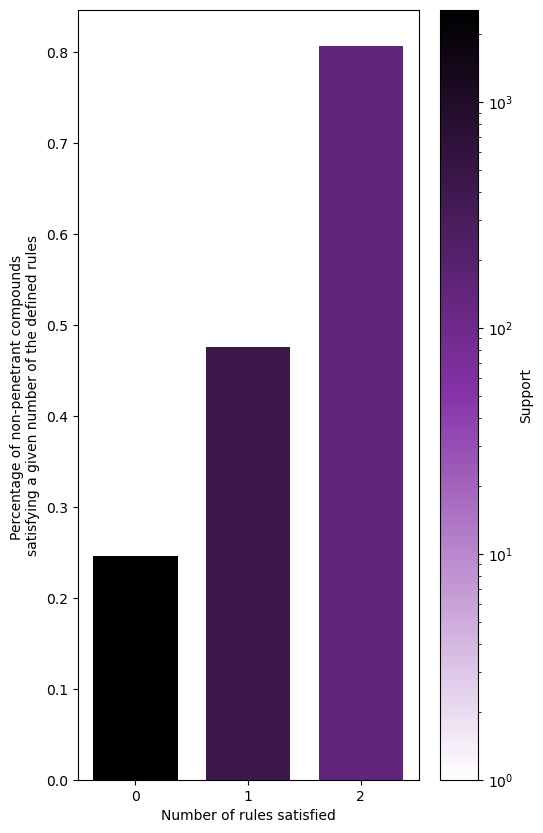

In [94]:

feature_ids_upper_bounded = [] #
feature_ids_lower_bounded = [l_cols[1], l_cols[10]]
# both_bounded = [top_feature_ids[8]]

# top_features = ["TopoPSA(NO)", "nHetero", "FNSA2", "RASA", "RPSA", "TPSA", "FPSA5", "FPSA4", 
#                 "PEOE_VSA6","nAcid","NdO", "SdO", "nBondsD", "GATS2c", "SLogP", "FNSA2", 
#                 "WNSA4", "WNSA5", "ATSC3s","TopoPSA",]

lower_bound = [110, 270]#0.037] ,10
# upper_bound = [-0.6]
# both_bounds = [30,40]

feature_ranges = []

n_criteria_met_nonpen = np.zeros((len(X_full_no_nan),))
n_criteria_met_pen = np.zeros((len(X_full_no_nan),))

for row in range(len(X_full_no_nan)): 
    for feature_id, feature in enumerate(feature_ids_lower_bounded): # 'nHBDon', 'nHBAcc'# 2050
        if (X_full_no_nan.iloc[row, feature] > lower_bound[feature_id]) and bbb_class[row] == 1: 
            n_criteria_met_nonpen[row] += 1
        if (X_full_no_nan.iloc[row, feature] > lower_bound[feature_id]) and bbb_class[row] == 0: 
            n_criteria_met_pen[row] += 1
    # for feature_id, feature in enumerate(both_bounded): # 'nHBDon', 'nHBAcc'# 2050
    #     if (X_full_no_nan.iloc[row, feature] > both_bounds[0]) and (X_full_no_nan.iloc[row, feature] < both_bounds[1]) and bbb_class[row] == 1: 
    #         n_criteria_met_nonpen[row] += 1
    #     if (X_full_no_nan.iloc[row, feature] > both_bounds[0]) and (X_full_no_nan.iloc[row, feature] < both_bounds[1]) and bbb_class[row] == 0: 
    #         n_criteria_met_pen[row] += 1
    for feature_id, feature in enumerate(feature_ids_upper_bounded): # 'nHBDon', 'nHBAcc'# 2050
        if (X_full_no_nan.iloc[row, feature] > upper_bound[feature_id]) and bbb_class[row] == 1: 
            n_criteria_met_nonpen[row] += 1
        if (X_full_no_nan.iloc[row, feature] > upper_bound[feature_id]) and bbb_class[row] == 0: 
            n_criteria_met_pen[row] += 1

total_features = len(feature_ids_lower_bounded) +len(feature_ids_upper_bounded) + 1 # len(both_bounded) +1 
ratio, n_non_pen, n_pen = np.zeros((total_features,)), np.zeros((total_features,)), np.zeros((total_features,))
for n_criteria in range(total_features):
    try: 
        ratio[n_criteria] = list(n_criteria_met_nonpen).count(n_criteria)/(list(n_criteria_met_nonpen).count(n_criteria)+list(n_criteria_met_pen).count(n_criteria))
        n_non_pen[n_criteria], n_pen[n_criteria] = list(n_criteria_met_nonpen).count(n_criteria), list(n_criteria_met_pen).count(n_criteria)
    except: 
        ratio[n_criteria] = 0


n_bbb_np = np.sum((bbb_class==1).astype(int))
n_bbb_p = np.sum((bbb_class==0).astype(int))

n_non_pen[0] = n_bbb_np
n_pen[0] = n_bbb_p

for n_criteria in range(1, total_features):
    n_non_pen[0] -= n_non_pen[n_criteria] 
    n_pen[0] -= n_pen[n_criteria]
    sum_vals = n_non_pen+n_pen

ratio[0] = n_non_pen[0]/(n_non_pen[0] + n_pen[0])


custom_cmap = LinearSegmentedColormap.from_list(
    'custom_cmap',
    ['#FFFFFF', colors[3], 'black'])


n_support = n_non_pen+n_pen

norm = LogNorm(vmin=1, vmax=np.max(n_support))


color_based_on_support = [custom_cmap(norm(n)) for n in n_support]
print(n_support)
print(n_non_pen/n_support)
plt.figure(figsize=(5.5,10))
plt.bar(range(len(ratio)), ratio[:], width=0.75, color=color_based_on_support) # #s=5, edgecolor="#6E94A8"
plt.xlabel('Number of rules satisfied')
plt.xticks(list(range(len(ratio))))
plt.ylabel('Percentage of non-penetrant compounds \nsatisfying a given number of the defined rules')




sm = cm.ScalarMappable(cmap=skyblue_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Support')

plt.savefig(f'./model_evaluation/{ds}/criteria_non_penetrant.png', dpi=300)

plt.show()

In [110]:
import numpy as np
import pandas as pd

top_feature_ids = l_cols

y = np.asarray(bbb_class, dtype=int)

feature1 = X_full_no_nan.iloc[:, int(top_feature_ids[1])].to_numpy()
feature2 = X_full_no_nan.iloc[:, int(top_feature_ids[10])].to_numpy()

rule1 = feature1 > 110
rule2 = feature2 > 270

rule_group = np.select(
    [
        ~rule1 & ~rule2,
        ~rule1 & rule2,
        rule1 & ~rule2,
        rule1 & rule2,
    ],
    [
        "Neither",
        "PNSA1 only",
        "TopoPSA(NO) only",
        "Both",
    ],
    default="Unknown",
)

group_order = [
    "Neither",
    "PNSA1 only",
    "TopoPSA(NO) only",
    "Both",
]

summary = (
    pd.DataFrame({
        "group": rule_group,
        "bbb_class": y,
    })
    .groupby("group", observed=True)["bbb_class"]
    .agg(
        nonpenetrant="sum",
        support="size",
        proportion_nonpenetrant="mean",
    )
    .reindex(group_order)
)

summary["penetrant"] = (
    summary["support"] - summary["nonpenetrant"]
)

print(summary)

                  nonpenetrant  support  proportion_nonpenetrant  penetrant
group                                                                      
Neither                    632     2569                 0.246010       1937
PNSA1 only                 111      289                 0.384083        178
TopoPSA(NO) only            97      148                 0.655405         51
Both                       121      150                 0.806667         29


In [111]:
from statsmodels.stats.proportion import proportion_confint

ci_low, ci_high = proportion_confint(
    count=summary["nonpenetrant"].to_numpy(),
    nobs=summary["support"].to_numpy(),
    alpha=0.05,
    method="wilson",
)

summary["ci_low"] = ci_low
summary["ci_high"] = ci_high

summary["error_low"] = (
    summary["proportion_nonpenetrant"] - summary["ci_low"]
)

summary["error_high"] = (
    summary["ci_high"] - summary["proportion_nonpenetrant"]
)

print(summary)

                  nonpenetrant  support  proportion_nonpenetrant  penetrant  \
group                                                                         
Neither                    632     2569                 0.246010       1937   
PNSA1 only                 111      289                 0.384083        178   
TopoPSA(NO) only            97      148                 0.655405         51   
Both                       121      150                 0.806667         29   

                    ci_low   ci_high  error_low  error_high  
group                                                        
Neither           0.229743  0.263035   0.016267    0.017025  
PNSA1 only        0.329876  0.441331   0.054207    0.057248  
TopoPSA(NO) only  0.575782  0.727166   0.079623    0.071760  
Both              0.736137  0.861881   0.070530    0.055214  


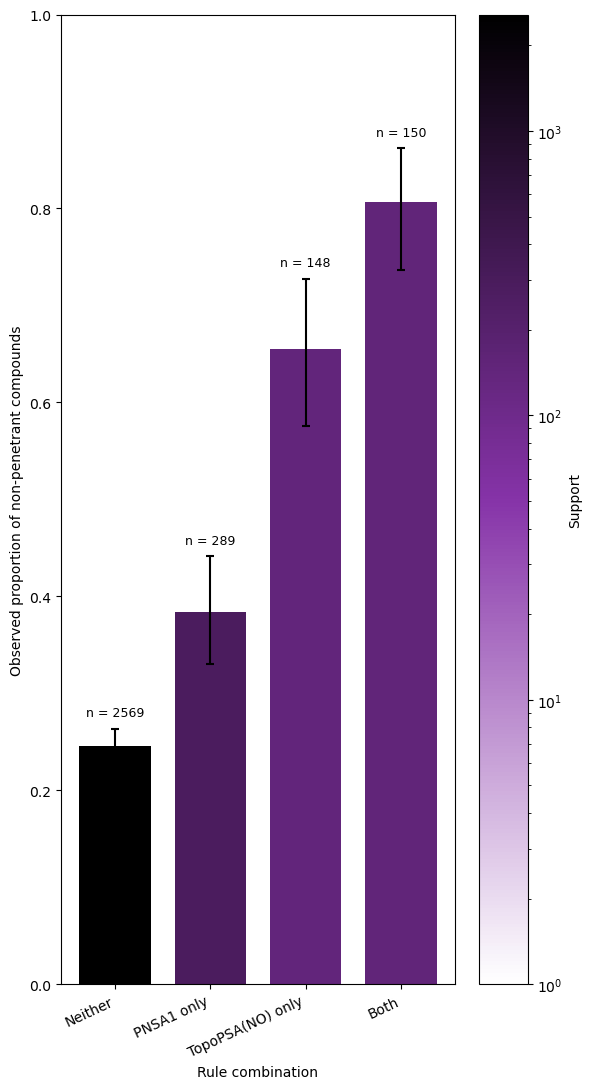

In [112]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LogNorm

valid = summary["support"].fillna(0) > 0
plot_summary = summary.loc[valid].copy()

norm = LogNorm(
    vmin=1,
    vmax=plot_summary["support"].max(),
)

bar_colors = [
    custom_cmap(norm(n))
    for n in plot_summary["support"]
]

x = np.arange(len(plot_summary))

fig, ax = plt.subplots(figsize=(6, 11))

bars = ax.bar(
    x,
    plot_summary["proportion_nonpenetrant"],
    color=bar_colors,
    width=0.75,
)

yerr = np.vstack([
    plot_summary["error_low"],
    plot_summary["error_high"],
])

# Black outline
ax.errorbar(
    x,
    plot_summary["proportion_nonpenetrant"],
    yerr=yerr,
    fmt="none",
    ecolor="black",
    elinewidth=1.5,
    capsize=3,
    capthick=1.5,
    zorder=3,
)

# Add count ratio and support above each confidence interval
for i, (_, row) in enumerate(plot_summary.iterrows()):
    nonpenetrant = int(row["nonpenetrant"])
    penetrant = int(row["penetrant"])
    support = int(row["support"])
    proportion = row["proportion_nonpenetrant"]

    # Top of the confidence interval
    upper_ci = proportion + row["error_high"]

    label = (
       # f"NP:P = {nonpenetrant}:{penetrant}\n"
        f"n = {support}"
    )

    ax.annotate(
        label,
        xy=(i, upper_ci),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        linespacing=1.2,
        annotation_clip=False,
    )

ax.set_xticks(x)
ax.set_xticklabels(
    plot_summary.index,
    rotation=25,
    ha="right",
)

ax.set_ylim(0, 1)
ax.set_xlabel("Rule combination")
ax.set_ylabel("Observed proportion of non-penetrant compounds")

sm = cm.ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Support")

fig.tight_layout()

plt.savefig('./model_rules', dpi=600)

plt.show()

In [117]:
bbb_class

array([1, 1, 1, ..., 0, 1, 1])

In [121]:
len(rule1)

3156

In [123]:
import statsmodels.formula.api as smf

# One row per compound
# nonpenetrant: 1 = non-penetrant, 0 = penetrant
# pnsa1_rule: 1 if the PNSA1 criterion is satisfied
# topopsa_rule: 1 if the TopoPSA(NO) criterion is satisfied
bbb_class

model = smf.logit(
    "bbb_class ~ rule2 * rule1",
    data=X_full_no_nan,
).fit()

print(model.summary())
print("\nOdds ratios:")
print(model.params.apply(np.exp))
print("\n95% CI for odds ratios:")
print(np.exp(model.conf_int()))

Optimization terminated successfully.
         Current function value: 0.568670
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:              bbb_class   No. Observations:                 3156
Model:                          Logit   Df Residuals:                     3152
Method:                           MLE   Df Model:                            3
Date:                Thu, 06 Aug 2026   Pseudo R-squ.:                 0.07478
Time:                        11:56:59   Log-Likelihood:                -1794.7
converged:                       True   LL-Null:                       -1939.8
Covariance Type:            nonrobust   LLR p-value:                 1.386e-62
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -1.1200      0.046    -24.449      0.000   

3820

In [134]:
import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportion_confint,
)

external_validation_df = pd.read_csv('../datasets/not_druglike_b3db_labelled.csv')

feature1 = external_validation_df.iloc[:,list(external_validation_df.columns).index("TopoPSA(NO)")].to_numpy()
feature2 = external_validation_df.iloc[:,list(external_validation_df.columns).index("PNSA1")].to_numpy()

rule1 = feature1 > 110
rule2 = feature2 > 270

external_validation_df['rule1'] = rule1
external_validation_df['rule2'] = rule2

# =============================================================================
# SETTINGS: EDIT THIS SECTION
# =============================================================================

# Replace this with the variable containing your external validation dataframe.
external = external_validation_df.copy()

OUTCOME_COL = "Class"

# Change this only if your encoding is different.
# Here, 1 means non-penetrant and 0 means penetrant.
NONPENETRANT_VALUE = 1

# The external dataframe must contain boolean columns called rule1 and rule2.
#
# Define them using EXACTLY the same fixed thresholds used in the original
# analysis. Do not optimize the thresholds using this external set.
#
# For example:
#
# external["rule1"] = (
#     pd.to_numeric(external["TopoPSA(NO)"], errors="coerce") > 110
# )
#
# external["rule2"] = (
#     pd.to_numeric(external["PNSA1"], errors="coerce") > YOUR_FIXED_THRESHOLD
# )
#
# Change the direction above if the original PNSA1 rule used "<" rather than ">".

RULE1_LABEL = "TopoPSA(NO)"
RULE2_LABEL = "PNSA1"

# Set this to True if you intentionally balanced the external classes.
EXTERNAL_SET_WAS_BALANCED = False

# =============================================================================
# END SETTINGS
# =============================================================================


required_columns = {OUTCOME_COL, "rule1", "rule2"}
missing_columns = sorted(required_columns - set(external.columns))

if missing_columns:
    raise KeyError(
        "The external dataframe is missing required columns: "
        f"{missing_columns}. Define rule1 and rule2 using the fixed thresholds."
    )


# Standardize the outcome.
external["nonpenetrant"] = (
    external[OUTCOME_COL] == NONPENETRANT_VALUE
).astype("Int64")

# Preserve missing descriptor/rule values rather than silently treating them
# as False.
external["rule1"] = external["rule1"].astype("boolean")
external["rule2"] = external["rule2"].astype("boolean")

n_before = len(external)

analysis_external = external.dropna(
    subset=["nonpenetrant", "rule1", "rule2"]
).copy()

analysis_external["nonpenetrant"] = (
    analysis_external["nonpenetrant"].astype(int)
)
analysis_external["rule1"] = analysis_external["rule1"].astype(bool)
analysis_external["rule2"] = analysis_external["rule2"].astype(bool)

print(f"External compounds supplied: {n_before}")
print(f"External compounds evaluated: {len(analysis_external)}")
print(f"Rows excluded for missing outcome/rules: {n_before - len(analysis_external)}")

if EXTERNAL_SET_WAS_BALANCED:
    print(
        "\nWARNING: This external set was class-balanced. "
        "Group proportions should not be interpreted as natural-prevalence "
        "probabilities of non-penetrance."
    )

External compounds supplied: 860
External compounds evaluated: 860
Rows excluded for missing outcome/rules: 0


In [136]:
group_order = [
    "Neither",
    f"{RULE2_LABEL} only",
    f"{RULE1_LABEL} only",
    "Both",
]

analysis_external["rule_group"] = np.select(
    [
        ~analysis_external["rule1"] & ~analysis_external["rule2"],
        ~analysis_external["rule1"] & analysis_external["rule2"],
        analysis_external["rule1"] & ~analysis_external["rule2"],
        analysis_external["rule1"] & analysis_external["rule2"],
    ],
    group_order,
    default=None,
)

analysis_external["rule_group"] = pd.Categorical(
    analysis_external["rule_group"],
    categories=group_order,
    ordered=True,
)

print(
    analysis_external[
        ["rule_group", "nonpenetrant"]
    ].value_counts(sort=False)
)

rule_group        nonpenetrant
Neither           0               181
                  1               143
PNSA1 only        0                70
                  1                50
TopoPSA(NO) only  0                35
                  1               118
Both              0                32
                  1               231
Name: count, dtype: int64


In [ ]:
summary_rows = []

for group in group_order:
    subset = analysis_external.loc[
        analysis_external["rule_group"] == group,
        "nonpenetrant",
    ]

    n_total = int(len(subset))
    n_nonpenetrant = int(subset.sum())
    n_penetrant = int(n_total - n_nonpenetrant)

    if n_total == 0:
        proportion = np.nan
        ci_low = np.nan
        ci_high = np.nan
    else:
        proportion = n_nonpenetrant / n_total

        ci_low, ci_high = proportion_confint(
            count=n_nonpenetrant,
            nobs=n_total,
            alpha=0.05,
            method="wilson",
        )

    summary_rows.append(
        {
            "rule_group": group,
            "n_total": n_total,
            "n_nonpenetrant": n_nonpenetrant,
            "n_penetrant": n_penetrant,
            "external_set_coverage": (
                n_total / len(analysis_external)
                if len(analysis_external) > 0
                else np.nan
            ),
            "nonpenetrant_proportion": proportion,
            "nonpenetrant_ci_low": ci_low,
            "nonpenetrant_ci_high": ci_high,
        }
    )

external_rule_summary = pd.DataFrame(summary_rows)

display(
    external_rule_summary.style.format(
        {
            "external_set_coverage": "{:.1%}",
            "nonpenetrant_proportion": "{:.1%}",
            "nonpenetrant_ci_low": "{:.1%}",
            "nonpenetrant_ci_high": "{:.1%}",
        }
    )
)

""

,rule_group,n_total,n_nonpenetrant,n_penetrant,external_set_coverage,nonpenetrant_proportion,nonpenetrant_ci_low,nonpenetrant_ci_high
0,Neither,324,143,181,37.7%,44.1%,38.8%,49.6%
1,PNSA1 only,120,50,70,14.0%,41.7%,33.2%,50.6%
2,TopoPSA(NO) only,153,118,35,17.8%,77.1%,69.9%,83.1%
3,Both,263,231,32,30.6%,87.8%,83.3%,91.2%


In [138]:
import numpy as np
import pandas as pd

y = np.asarray(bbb_class, dtype=int)

rule_hits = []

for feature, bound in zip(feature_ids_lower_bounded, lower_bound):
    rule_hits.append(
        X_full_no_nan.iloc[:, int(feature)].to_numpy() > bound
    )

# Add these if used:
#
# for feature, bound in zip(feature_ids_upper_bounded, upper_bound):
#     rule_hits.append(
#         X_full_no_nan.iloc[:, int(feature)].to_numpy() < bound
#     )

rule_hits = np.column_stack(rule_hits)
n_rules = rule_hits.sum(axis=1)

levels = np.arange(rule_hits.shape[1] + 1)

results = pd.DataFrame(index=levels)
results.index.name = "n_rules"

results["nonpenetrant"] = [
    np.sum((n_rules == k) & (y == 1))
    for k in levels
]

results["penetrant"] = [
    np.sum((n_rules == k) & (y == 0))
    for k in levels
]

results["support"] = (
    results["nonpenetrant"] + results["penetrant"]
)

results["proportion_nonpenetrant"] = (
    results["nonpenetrant"] / results["support"]
)

print(results)

         nonpenetrant  penetrant  support  proportion_nonpenetrant
n_rules                                                           
0                 632       1937     2569                 0.246010
1                 208        229      437                 0.475973
2                 121         29      150                 0.806667


In [139]:
from scipy.stats import chi2_contingency

# Remove empty rule-count categories
tested = results.loc[
    results["support"] > 0,
    ["penetrant", "nonpenetrant"]
]

chi2, p_chi2, dof, expected = chi2_contingency(tested.to_numpy())

n = tested.to_numpy().sum()
r, c = tested.shape

cramers_v = np.sqrt(
    chi2 / (n * min(r - 1, c - 1))
)

print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p = {p_chi2:.3g}")
print(f"Cramer's V = {cramers_v:.3f}")
print("Expected counts:")
print(expected)

Chi-square = 280.780
df = 2
p = 1.07e-61
Cramer's V = 0.298
Expected counts:
[[1786.74112801  782.25887199]
 [ 303.93377693  133.06622307]
 [ 104.32509506   45.67490494]]


In [140]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from pathlib import Path
from matplotlib.colors import LogNorm
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests


# =============================================================================
# SIGNIFICANCE TESTS
# =============================================================================

# These are the full set of prespecified comparisons used for Holm correction.
all_comparisons = [
    ("PNSA1 only", "Neither"),
    ("TopoPSA(NO) only", "Neither"),
    ("Both", "Neither"),
    ("Both", "PNSA1 only"),
    ("Both", "TopoPSA(NO) only"),
]

test_rows = []

for group_a, group_b in all_comparisons:
    row_a = summary.loc[group_a]
    row_b = summary.loc[group_b]

    contingency_table = np.array([
        [
            int(row_a["nonpenetrant"]),
            int(row_a["penetrant"]),
        ],
        [
            int(row_b["nonpenetrant"]),
            int(row_b["penetrant"]),
        ],
    ])

    odds_ratio, p_value = fisher_exact(
        contingency_table,
        alternative="two-sided",
    )

    test_rows.append({
        "group_a": group_a,
        "group_b": group_b,
        "odds_ratio": odds_ratio,
        "p_value": p_value,
    })

significance_results = pd.DataFrame(test_rows)

significance_results["p_holm"] = multipletests(
    significance_results["p_value"],
    method="holm",
)[1]


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


significance_results["significance"] = (
    significance_results["p_holm"].apply(p_to_stars)
)

display(significance_results)

,group_a,group_b,odds_ratio,p_value,p_holm,significance
0,PNSA1 only,Neither,1.911241,9.346693e-07,1.869339e-06,***
1,TopoPSA(NO) only,Neither,5.829269,3.612562e-24,1.445025e-23,***
2,Both,Neither,12.787920,4.785216e-44,2.392608e-43,***
3,Both,PNSA1 only,6.690898,1.277785e-17,3.833356e-17,***
4,Both,TopoPSA(NO) only,2.193743,3.940734e-03,3.940734e-03,**


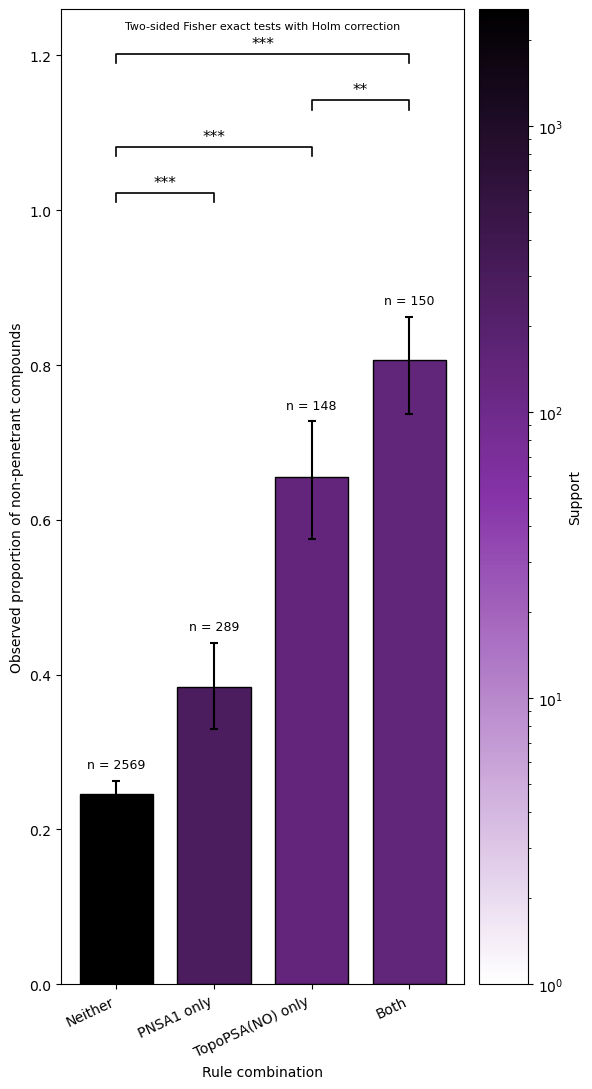

In [141]:
# =============================================================================
# PLOT
# =============================================================================

valid = summary["support"].fillna(0) > 0
plot_summary = summary.loc[valid].copy()

# Keep the intended order.
group_order = [
    "Neither",
    "PNSA1 only",
    "TopoPSA(NO) only",
    "Both",
]

plot_summary = plot_summary.loc[
    [group for group in group_order if group in plot_summary.index]
]

norm = LogNorm(
    vmin=1,
    vmax=plot_summary["support"].max(),
)

bar_colors = [
    custom_cmap(norm(n))
    for n in plot_summary["support"]
]

x = np.arange(len(plot_summary))

fig, ax = plt.subplots(figsize=(6, 11))

bars = ax.bar(
    x,
    plot_summary["proportion_nonpenetrant"],
    color=bar_colors,
    edgecolor="black",
    linewidth=1,
    width=0.75,
)

yerr = np.vstack([
    plot_summary["error_low"],
    plot_summary["error_high"],
])

ax.errorbar(
    x,
    plot_summary["proportion_nonpenetrant"],
    yerr=yerr,
    fmt="none",
    ecolor="black",
    elinewidth=1.5,
    capsize=3,
    capthick=1.5,
    zorder=3,
)


# =============================================================================
# SUPPORT LABELS
# =============================================================================

for i, (_, row) in enumerate(plot_summary.iterrows()):
    support = int(row["support"])
    proportion = row["proportion_nonpenetrant"]
    upper_ci = proportion + row["error_high"]

    ax.annotate(
        f"n = {support}",
        xy=(i, upper_ci),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        annotation_clip=False,
    )


# =============================================================================
# SIGNIFICANCE BRACKETS
# =============================================================================

group_to_x = {
    group: position
    for position, group in enumerate(plot_summary.index)
}


def add_significance_bracket(
    ax,
    group_a,
    group_b,
    label,
    y,
    bracket_height=0.012,
    linewidth=1.2,
):
    x1 = group_to_x[group_a]
    x2 = group_to_x[group_b]

    ax.plot(
        [x1, x1, x2, x2],
        [y, y + bracket_height, y + bracket_height, y],
        color="black",
        linewidth=linewidth,
        clip_on=False,
    )

    ax.text(
        (x1 + x2) / 2,
        y + bracket_height + 0.004,
        label,
        ha="center",
        va="bottom",
        fontsize=11,
        clip_on=False,
    )


def get_significance_label(group_a, group_b):
    match = significance_results[
        (
            (significance_results["group_a"] == group_a)
            & (significance_results["group_b"] == group_b)
        )
        |
        (
            (significance_results["group_a"] == group_b)
            & (significance_results["group_b"] == group_a)
        )
    ]

    if len(match) != 1:
        raise ValueError(
            f"Expected exactly one test for {group_a!r} versus {group_b!r}."
        )

    return match.iloc[0]["significance"]


# Comparisons displayed in the figure.
# These emphasize whether each candidate rule improves over Neither,
# and whether PNSA1 adds information among TopoPSA(NO)-positive compounds.
comparisons_to_plot = [
    ("PNSA1 only", "Neither", 1.01),
    ("TopoPSA(NO) only", "Neither", 1.07),
    ("Both", "TopoPSA(NO) only", 1.13),
    ("Both", "Neither", 1.19),
]

for group_a, group_b, y_position in comparisons_to_plot:
    add_significance_bracket(
        ax=ax,
        group_a=group_a,
        group_b=group_b,
        label=get_significance_label(group_a, group_b),
        y=y_position,
    )


# =============================================================================
# FORMATTING
# =============================================================================

ax.set_xticks(x)

ax.set_xticklabels(
    plot_summary.index,
    rotation=25,
    ha="right",
)

# Extra space above 1.0 is needed for the significance brackets.
ax.set_ylim(0, 1.26)

ax.set_xlabel("Rule combination")
ax.set_ylabel("Observed proportion of non-penetrant compounds")

sm = cm.ScalarMappable(
    cmap=custom_cmap,
    norm=norm,
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=ax,
    pad=0.03,
)

cbar.set_label("Support")

# Explain the significance notation directly on the figure.
ax.text(
    0.5,
    1.245,
    "Two-sided Fisher exact tests with Holm correction",
    transform=ax.get_yaxis_transform(),
    ha="center",
    va="top",
    fontsize=8,
)

fig.tight_layout()

output_path = Path("./model_rules.png")
output_path.parent.mkdir(parents=True, exist_ok=True)

fig.savefig(
    output_path,
    dpi=600,
    bbox_inches="tight",
)

plt.show()

In [27]:

feature_ids_upper_bounded = []
feature_ids_lower_bounded = subset_feature_id[:3]
lower_bound = [110, 110, 250]

feature_ranges = []

n_criteria_met_nonpen = np.zeros((len(X_full_no_nan),))
n_criteria_met_pen = np.zeros((len(X_full_no_nan),))

for row in range(len(X_full_no_nan)): 
    for feature_id, feature in enumerate(feature_ids_lower_bounded): # 'nHBDon', 'nHBAcc'# 2050
        if (X_full_no_nan.iloc[row, feature] > lower_bound[feature_id]) and bbb_class[row] == 1: 
            n_criteria_met_nonpen[row] += 1
        if (X_full_no_nan.iloc[row, feature] > lower_bound[feature_id]) and bbb_class[row] == 0: 
            n_criteria_met_pen[row] += 1

total_features = len(feature_ids_lower_bounded) +len(feature_ids_upper_bounded) +1 
ratio, n_non_pen, n_pen = np.zeros((total_features,)), np.zeros((total_features,)), np.zeros((total_features,))
for n_criteria in range(total_features):
    try: 
        ratio[n_criteria] = list(n_criteria_met_nonpen).count(n_criteria)/(list(n_criteria_met_nonpen).count(n_criteria)+list(n_criteria_met_pen).count(n_criteria))
        n_non_pen[n_criteria], n_pen[n_criteria] = list(n_criteria_met_nonpen).count(n_criteria), list(n_criteria_met_pen).count(n_criteria)
    except: 
        ratio[n_criteria] = 0


n_bbb_np = np.sum((bbb_class==1).astype(int))
n_bbb_p = np.sum((bbb_class==0).astype(int))

n_non_pen[0] = n_bbb_np
n_pen[0] = n_bbb_p

for n_criteria in range(1, total_features):
    n_non_pen[0] -= n_non_pen[n_criteria] 
    n_pen[0] -= n_pen[n_criteria]
    sum_vals = n_non_pen+n_pen

ratio[0] = n_non_pen[0]/(n_non_pen[0] + n_pen[0])


custom_cmap = LinearSegmentedColormap.from_list(
    'custom_cmap',
    ['#FFFFFF', colors[3], 'black'])


n_support = n_non_pen+n_pen

norm = LogNorm(vmin=1, vmax=np.max(n_support))


color_based_on_support = [custom_cmap(norm(n)) for n in n_support]
print(n_support)
print(n_non_pen/n_support)
plt.figure(figsize=(5.5,10))
plt.bar(range(len(ratio)), ratio[:], width=0.75, color=color_based_on_support) # #s=5, edgecolor="#6E94A8"
plt.xlabel('Number of rules satisfied')
plt.xticks(list(range(len(ratio))))
plt.ylabel('Percentage of non-penetrant compounds \nsatisfying a given number of the defined rules')


sm = cm.ScalarMappable(cmap=skyblue_cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm)
cbar.set_label('Support')

plt.savefig(f'./model_evaluation/{ds}/criteria_non_penetrant.png', dpi=300)

plt.show()

NameError: name 'subset_feature_id' is not defined